# CSE 547 Deep Learning — Final Project
## Complete Pipeline: Parts 1–6
**Dataset:** FLIR ADAS Thermal Dataset v2  
**Classes:** bike · bus · car · person · sign · motor · light · truck  
**Structure:** Part 1 (CNN Architectures) · Part 2 (Regularization) · Part 3 (Transfer Learning) · Part 4 (AutoEncoder) · Part 5 (Analysis) · Part 6 (Final Optimization)

## 1. Environment Check


In [2]:
import os
import json
import math
import random
import shutil
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.applications import VGG16

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Working dir:", os.getcwd())
print("Kaggle input exists:", os.path.exists('/kaggle/input'))


TensorFlow: 2.19.0
Num GPUs Available: 1
Working dir: /kaggle/working
Kaggle input exists: True


## 2. Inspect Attached Kaggle Inputs


In [3]:
def print_kaggle_tree(root='/kaggle/input', max_depth=3, max_entries=20):
    root = Path(root)
    if not root.exists():
        print(f"{root} does not exist.")
        return

    for current_root, dirs, files in os.walk(root):
        rel = Path(current_root).relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(f"{indent}{Path(current_root).name}/")
        for d in sorted(dirs)[:max_entries]:
            print(f"{indent}  {d}/")
        for f in sorted(files)[:max_entries]:
            print(f"{indent}  {f}")
        if len(dirs) > max_entries or len(files) > max_entries:
            print(f"{indent}  ...")

print_kaggle_tree()


input/
  datasets/
  datasets/
    waelbouchaala/
    waelbouchaala/
      cse-547-final-project/
      cse-547-final-project/
        Train_IR/
        Train_RGB/
        Val_IR/
        Val_RGB/


## 3. Configure Dataset Paths
Edit only this section after inspecting `/kaggle/input/...`.


In [4]:
# =========================
# EDIT THESE PATHS
# =========================
DATASET_ROOT = Path('/kaggle/input/datasets/waelbouchaala/cse-547-final-project')  # change this if needed

DATA_PATHS = {
    'rgb': {
        'train': DATASET_ROOT / 'Train_RGB' / 'train_rgb_patches',
        'val':   DATASET_ROOT / 'Val_RGB' / 'val_rgb_patches',
    },
    'ir': {
        'train': DATASET_ROOT / 'Train_IR' / 'train_thermal_patches',
        'val':   DATASET_ROOT / 'Val_IR' / 'val_thermal_patches',
    }
}

PATCH_INFO_PATHS = {'rgb': None, 'ir': None}
ORIGINAL_IMAGE_ROOTS = {'rgb': None, 'ir': None}


## 4. Path Validation


In [5]:
CLASS_NAMES = ['bike', 'bus', 'car', 'person', 'sign', 'motor', 'light', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = (64, 64)
DEFAULT_BATCH_SIZE = 128
SEED = 42
MIN_EPOCHS = 50
PATIENCE = 10
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_ROOT = Path('/kaggle/working/final_project_outputs')
FIGURE_ROOT = OUTPUT_ROOT / 'figures'
TABLE_ROOT = OUTPUT_ROOT / 'tables'
MODEL_ROOT = OUTPUT_ROOT / 'models'
ANALYSIS_ROOT = OUTPUT_ROOT / 'analysis'
for p in [OUTPUT_ROOT, FIGURE_ROOT, TABLE_ROOT, MODEL_ROOT, ANALYSIS_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

MASTER_SUMMARY_CSV = TABLE_ROOT / 'master_experiment_summary.csv'

for modality in ['rgb', 'ir']:
    print(f"\n{modality.upper()}")
    print("Train path:", DATA_PATHS[modality]['train'])
    print("Train exists:", DATA_PATHS[modality]['train'].exists())
    print("Val path:  ", DATA_PATHS[modality]['val'])
    print("Val exists:", DATA_PATHS[modality]['val'].exists())
    if DATA_PATHS[modality]['train'].exists():
        print("Train subfolders:", sorted([p.name for p in DATA_PATHS[modality]['train'].iterdir() if p.is_dir()])[:20])
    if DATA_PATHS[modality]['val'].exists():
        print("Val subfolders:  ", sorted([p.name for p in DATA_PATHS[modality]['val'].iterdir() if p.is_dir()])[:20])



RGB
Train path: /kaggle/input/datasets/waelbouchaala/cse-547-final-project/Train_RGB/train_rgb_patches
Train exists: True
Val path:   /kaggle/input/datasets/waelbouchaala/cse-547-final-project/Val_RGB/val_rgb_patches
Val exists: True
Train subfolders: ['bike', 'bus', 'car', 'light', 'motor', 'person', 'sign', 'truck']
Val subfolders:   ['bike', 'bus', 'car', 'light', 'motor', 'person', 'sign', 'truck']

IR
Train path: /kaggle/input/datasets/waelbouchaala/cse-547-final-project/Train_IR/train_thermal_patches
Train exists: True
Val path:   /kaggle/input/datasets/waelbouchaala/cse-547-final-project/Val_IR/val_thermal_patches
Val exists: True
Train subfolders: ['bike', 'bus', 'car', 'light', 'motor', 'person', 'sign', 'truck']
Val subfolders:   ['bike', 'bus', 'car', 'light', 'motor', 'person', 'sign', 'truck']


## 5. Data Loading Utilities


In [6]:
def normalize_image(x: tf.Tensor, y: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

def build_augmentation(name: str):
    if name == 'none':
        return layers.Lambda(lambda x: x, name='aug_none_identity')
    if name == 'light':
        return tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
        ], name='aug_light')
    if name == 'medium':
        return tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.08),
            layers.RandomZoom(0.10),
            layers.RandomContrast(0.10),
        ], name='aug_medium')
    if name == 'strong':
        return tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.12),
            layers.RandomZoom(0.15),
            layers.RandomTranslation(0.08, 0.08),
            layers.RandomContrast(0.15),
        ], name='aug_strong')
    if name == 'geom_heavy':
        return tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.20),
            layers.RandomTranslation(0.10, 0.10),
        ], name='aug_geom_heavy')
    raise ValueError(f'Unknown augmentation option: {name}')

def load_datasets_from_paths(train_dir: Path, val_dir: Path, image_size=IMAGE_SIZE, batch_size=DEFAULT_BATCH_SIZE, seed=SEED):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=batch_size,
        shuffle=True,
        seed=seed,
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        labels='inferred',
        label_mode='int',
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=batch_size,
        shuffle=False,
    )
    train_ds = train_ds.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_ds.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return train_ds, val_ds

def load_modality_datasets(modality: str, batch_size=DEFAULT_BATCH_SIZE):
    return load_datasets_from_paths(
        train_dir=DATA_PATHS[modality]['train'],
        val_dir=DATA_PATHS[modality]['val'],
        batch_size=batch_size,
    )


## 6. Metrics, Callbacks, and Core Helpers


In [7]:
def count_total_params(model: tf.keras.Model) -> int:
    return int(model.count_params())

def count_trainable_params(model: tf.keras.Model) -> int:
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

def macro_f1_from_probs(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    y_pred = np.argmax(y_prob, axis=1)
    return float(f1_score(y_true, y_pred, average='macro'))

def save_json(path: Path, data: Dict[str, Any]):
    def default_serializer(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        return str(obj)
    with open(path, 'w') as f:
        json.dump(data, f, indent=2, default=default_serializer)

def append_to_master_summary(record: Dict[str, Any]):
    row = pd.DataFrame([{k: (v.item() if isinstance(v, (np.integer, np.floating)) else v) for k, v in record.items()}])
    if MASTER_SUMMARY_CSV.exists():
        df = pd.read_csv(MASTER_SUMMARY_CSV)
        df = pd.concat([df, row], ignore_index=True).drop_duplicates()
    else:
        df = row
    df.to_csv(MASTER_SUMMARY_CSV, index=False)
    return df

def get_standard_callbacks(save_dir: Path):
    save_dir.mkdir(parents=True, exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(filepath=str(save_dir / 'best_model.keras'), monitor='val_loss', save_best_only=True, verbose=0),
        callbacks.CSVLogger(str(save_dir / 'history.csv')),
    ]

def compile_classifier(model: tf.keras.Model, learning_rate: float):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

def compile_autoencoder(model: tf.keras.Model, learning_rate: float):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'],
    )

def evaluate_classifier(model: tf.keras.Model, ds: tf.data.Dataset):
    y_true, y_prob = [], []
    for xb, yb in ds:
        preds = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy())
        y_prob.extend(preds)
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.argmax(y_prob, axis=1)
    return {
        'accuracy': float(np.mean(y_true == y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'report': classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }

def evaluate_classifier_arrays(model: tf.keras.Model, x_data: np.ndarray, y_true: np.ndarray):
    y_prob = model.predict(x_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return {
        'accuracy': float(np.mean(y_true == y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'report': classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }

def plot_four_metrics(x_labels, train_acc, val_acc, train_f1, val_f1, title, x_axis_label, save_path, x_log_scale=False):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    def draw(ax, y, series_title, marker):
        if x_log_scale:
            ax.plot(x_labels, y, marker=marker, label=series_title)
            ax.set_xscale('log')
        else:
            ax.plot(range(len(x_labels)), y, marker=marker, label=series_title)
            ax.set_xticks(range(len(x_labels)))
            ax.set_xticklabels(x_labels, rotation=30, ha='right')
        ax.set_title(series_title); ax.set_xlabel(x_axis_label); ax.legend(); ax.grid(True, alpha=0.3)
    draw(axes[0, 0], train_acc, 'Training Accuracy', 'o')
    draw(axes[0, 1], val_acc, 'Validation Accuracy', 's')
    draw(axes[1, 0], train_f1, 'Training F1', '^')
    draw(axes[1, 1], val_f1, 'Validation F1', 'd')
    fig.suptitle(title); fig.tight_layout(); fig.savefig(save_path, dpi=200, bbox_inches='tight'); plt.close(fig)

def plot_confusion(cm, save_path, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right'); ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center')
    fig.colorbar(im); fig.tight_layout(); fig.savefig(save_path, dpi=200, bbox_inches='tight'); plt.close(fig)


## 7. Model Builders


In [8]:
def conv_block(x, filters: int, kernel_size: int = 3, pool: bool = True, l2_value: float = 0.0):
    x = layers.Conv2D(
        filters, kernel_size, padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(l2_value) if l2_value > 0 else None,
    )(x)
    x = layers.BatchNormalization()(x)
    if pool:
        x = layers.MaxPooling2D()(x)
    return x

def build_custom_cnn(input_shape, conv_filters, dense_units, dropout=0.0, weight_decay=0.0, augmentation_name='none', num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = build_augmentation(augmentation_name)(inputs)
    for f in conv_filters:
        x = conv_block(x, f, pool=True, l2_value=weight_decay)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(
        dense_units, activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay) if weight_decay > 0 else None,
    )(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name=f"cnn_{'_'.join(map(str, conv_filters))}_{dense_units}")

def freeze_vgg_by_level(vgg: tf.keras.Model, freeze_option: str):
    if freeze_option == 'freeze_all_features':
        for layer in vgg.layers:
            layer.trainable = False
        return
    block_cut_map = {
        'freeze_blocks_1_to_3': {'block1', 'block2', 'block3'},
        'freeze_blocks_1_to_2': {'block1', 'block2'},
    }
    frozen_prefixes = block_cut_map[freeze_option]
    for layer in vgg.layers:
        layer.trainable = True
        if any(layer.name.startswith(prefix) for prefix in frozen_prefixes):
            layer.trainable = False

def build_vgg16_transfer(input_shape, freeze_option, dense_units=(256, 64), dropout=0.3, weight_decay=1e-4, augmentation_name='light', num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = build_augmentation(augmentation_name)(inputs)
    x = tf.keras.applications.vgg16.preprocess_input(x * 255.0)
    vgg = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    freeze_vgg_by_level(vgg, freeze_option)
    x = vgg(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units[0], activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units[1], activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name=f'vgg16_{freeze_option}')

def build_encoder_decoder(input_shape, encoder_filters, latent_channels, weight_decay=0.0):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for f in encoder_filters:
        x = layers.Conv2D(
            f, 3, strides=2, padding='same', activation='relu',
            kernel_regularizer=regularizers.l2(weight_decay) if weight_decay > 0 else None,
        )(x)
        x = layers.BatchNormalization()(x)
    encoded = layers.Conv2D(latent_channels, 3, padding='same', activation='relu', name='latent_conv')(x)
    encoder = models.Model(inputs, encoded, name='encoder')

    latent_inputs = layers.Input(shape=encoder.output_shape[1:])
    x = latent_inputs
    for f in reversed(encoder_filters):
        x = layers.Conv2DTranspose(
            f, 3, strides=2, padding='same', activation='relu',
            kernel_regularizer=regularizers.l2(weight_decay) if weight_decay > 0 else None,
        )(x)
        x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(input_shape[-1], 3, padding='same', activation='sigmoid')(x)
    decoder = models.Model(latent_inputs, outputs, name='decoder')

    autoencoder = models.Model(inputs, decoder(encoder(inputs)), name='conv_autoencoder')
    return encoder, decoder, autoencoder

def build_feature_classifier(feature_shape, dense_units=(256, 64), dropout=0.3, weight_decay=1e-4, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=feature_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(dense_units[0], activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units[1], activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='ae_feature_classifier')


## 8. Training Functions


In [9]:
@dataclass
class TrainConfig:
    experiment_name: str
    modality: str
    model_type: str
    input_shape: Tuple[int, int, int]
    batch_size: int = DEFAULT_BATCH_SIZE
    epochs: int = MIN_EPOCHS
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    dropout: float = 0.0
    augmentation_name: str = 'none'
    extra: Optional[Dict[str, Any]] = None

def fit_classifier(model, train_ds, val_ds, config: TrainConfig, save_dir: Path):
    compile_classifier(model, config.learning_rate)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=max(config.epochs, MIN_EPOCHS),
        callbacks=get_standard_callbacks(save_dir),
        verbose=1,
    )
    train_metrics = evaluate_classifier(model, train_ds)
    val_metrics = evaluate_classifier(model, val_ds)
    return {
        'history': history.history,
        'post_train_metrics': {
            'train_accuracy': train_metrics['accuracy'],
            'train_f1_macro': train_metrics['f1_macro'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1_macro': val_metrics['f1_macro'],
        },
        'metrics': val_metrics,
        'train_metrics': train_metrics,
        'total_params': count_total_params(model),
        'trainable_params': count_trainable_params(model),
        'model_name': model.name,
    }

def train_ae_only(autoencoder, train_ds, val_ds, learning_rate, save_dir: Path, epochs=MIN_EPOCHS):
    compile_autoencoder(autoencoder, learning_rate)
    x_train = train_ds.map(lambda x, y: (x, x), num_parallel_calls=AUTOTUNE)
    x_val = val_ds.map(lambda x, y: (x, x), num_parallel_calls=AUTOTUNE)
    history = autoencoder.fit(
        x_train,
        validation_data=x_val,
        epochs=max(epochs, MIN_EPOCHS),
        callbacks=get_standard_callbacks(save_dir),
        verbose=1,
    )
    return {'history': history.history}

def extract_features(encoder, ds):
    feat_list, label_list = [], []
    for xb, yb in ds:
        features = encoder.predict(xb, verbose=0)
        feat_list.append(features)
        label_list.append(yb.numpy())
    return np.concatenate(feat_list, axis=0), np.concatenate(label_list, axis=0)

def train_classifier_on_features(encoder, train_ds, val_ds, clf_config, save_dir: Path):
    x_train_feat, y_train = extract_features(encoder, train_ds)
    x_val_feat, y_val = extract_features(encoder, val_ds)
    clf = build_feature_classifier(
        feature_shape=x_train_feat.shape[1:],
        dense_units=clf_config.get('dense_units', (256, 64)),
        dropout=clf_config.get('dropout', 0.3),
        weight_decay=clf_config.get('weight_decay', 1e-4),
    )
    compile_classifier(clf, clf_config.get('learning_rate', 1e-3))
    early = callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)
    reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
    history = clf.fit(
        x_train_feat, y_train,
        validation_data=(x_val_feat, y_val),
        epochs=max(clf_config.get('epochs', MIN_EPOCHS), MIN_EPOCHS),
        batch_size=clf_config.get('batch_size', DEFAULT_BATCH_SIZE),
        callbacks=[early, reduce],
        verbose=1,
    )
    train_metrics = evaluate_classifier_arrays(clf, x_train_feat, y_train)
    val_metrics = evaluate_classifier_arrays(clf, x_val_feat, y_val)
    return {
        'history': history.history,
        'post_train_metrics': {
            'train_accuracy': train_metrics['accuracy'],
            'train_f1_macro': train_metrics['f1_macro'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1_macro': val_metrics['f1_macro'],
        },
        'metrics': val_metrics,
        'train_metrics': train_metrics,
        'classifier': clf,
        'feature_shape': tuple(x_train_feat.shape[1:]),
        'trainable_params': count_trainable_params(clf),
        'total_params': count_total_params(clf),
    }


## 9. Plotting and Save Helpers


In [4]:
def save_json(path: Path, data: Dict[str, Any]):
    path.parent.mkdir(parents=True, exist_ok=True)

    def default_serializer(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, (np.integer, np.floating)):
            return obj.item()
        return str(obj)

    with open(path, 'w') as f:
        json.dump(data, f, indent=2, default=default_serializer)

def plot_four_metrics(x_labels, train_acc, val_acc, train_f1, val_f1, title, x_axis_label, save_path, x_log_scale=False):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    def draw(ax, y, series_title, marker):
        if x_log_scale:
            ax.plot(x_labels, y, marker=marker, label=series_title)
            ax.set_xscale('log')
        else:
            ax.plot(range(len(x_labels)), y, marker=marker, label=series_title)
            ax.set_xticks(range(len(x_labels)))
            ax.set_xticklabels(x_labels, rotation=30, ha='right')
        ax.set_title(series_title)
        ax.set_xlabel(x_axis_label)
        ax.legend()
        ax.grid(True, alpha=0.3)

    draw(axes[0, 0], train_acc, 'Training Accuracy', 'o')
    draw(axes[0, 1], val_acc, 'Validation Accuracy', 's')
    draw(axes[1, 0], train_f1, 'Training F1', '^')
    draw(axes[1, 1], val_f1, 'Validation F1', 'd')

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

def plot_confusion(cm, save_path, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center')
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


## 10. Part 1 — CNN Architecture Configs and Runner


In [11]:
def get_part1_cnn_configs(modality: str):
    input_shape = (*IMAGE_SIZE, 3)

    if modality == 'rgb':
        return [
            {'name': f'{modality}_cnn_1_tiny',   'input_shape': input_shape, 'conv_filters': [4],                 'dense_units': 8,   'dropout': 0.0, 'weight_decay': 0.0,  'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_2_small',  'input_shape': input_shape, 'conv_filters': [16, 32],            'dense_units': 64,  'dropout': 0.1, 'weight_decay': 0.0,  'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_3_medium', 'input_shape': input_shape, 'conv_filters': [128, 256, 512],     'dense_units': 512, 'dropout': 0.2, 'weight_decay': 1e-5, 'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_4_large',  'input_shape': input_shape, 'conv_filters': [512, 1024, 2048, 2048], 'dense_units': 2048, 'dropout': 0.3, 'weight_decay': 1e-4, 'augmentation_name': 'none'},
        ]

    elif modality == 'ir':
        return [
            {'name': f'{modality}_cnn_1_tiny',   'input_shape': input_shape, 'conv_filters': [4],               'dense_units': 8,   'dropout': 0.0, 'weight_decay': 0.0,  'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_2_small',  'input_shape': input_shape, 'conv_filters': [16, 32],          'dense_units': 64,  'dropout': 0.1, 'weight_decay': 0.0,  'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_3_medium', 'input_shape': input_shape, 'conv_filters': [128, 256, 512],   'dense_units': 512, 'dropout': 0.2, 'weight_decay': 1e-5, 'augmentation_name': 'none'},
            {'name': f'{modality}_cnn_4_large',  'input_shape': input_shape, 'conv_filters': [256, 512, 512, 512], 'dense_units': 1024, 'dropout': 0.3, 'weight_decay': 1e-4, 'augmentation_name': 'none'},
        ]

    else:
        raise ValueError(f"Unknown modality: {modality}")

def count_params_for_config(cfg):
    model = build_custom_cnn(
        cfg['input_shape'], cfg['conv_filters'], cfg['dense_units'],
        cfg['dropout'], cfg['weight_decay'], cfg['augmentation_name']
    )
    return model.count_params()

def validate_param_scaling(modality: str, auto_fix: bool = True):
    configs = get_part1_cnn_configs(modality)

    if auto_fix:
        for i in range(1, len(configs)):
            prev_params = count_params_for_config(configs[i - 1])
            curr_params = count_params_for_config(configs[i])

            while curr_params < 10 * prev_params:
                # For IR model 4, do not let it grow without bound
                if modality == 'ir' and i == 3:
                    # Grow only up to a controlled cap
                    if configs[i]['dense_units'] < 2048:
                        configs[i]['dense_units'] *= 2
                    elif max(configs[i]['conv_filters']) < 1024:
                        configs[i]['conv_filters'] = [min(f * 2, 1024) for f in configs[i]['conv_filters']]
                    else:
                        break
                else:
                    if configs[i]['dense_units'] < 8192:
                        configs[i]['dense_units'] *= 2
                    else:
                        configs[i]['conv_filters'] = [f * 2 for f in configs[i]['conv_filters']]

                curr_params = count_params_for_config(configs[i])

    params = [count_params_for_config(cfg) for cfg in configs]
    scaling_df = pd.DataFrame({
        'experiment': [cfg['name'] for cfg in configs],
        'params': params
    })
    scaling_df['ratio_vs_previous'] = scaling_df['params'] / scaling_df['params'].shift(1)
    scaling_df.to_csv(TABLE_ROOT / f'{modality}_part1_param_scaling.csv', index=False)
    print(scaling_df)

    for i in range(1, len(params)):
        assert params[i] >= 10 * params[i - 1], f"{modality}: model {configs[i]['name']} is not >=10x previous model"

    print(f'10x parameter scaling verified for {modality.upper()}.')
    return configs

def run_part1_for_modality(modality: str):
    train_ds, val_ds = load_modality_datasets(modality, batch_size=DEFAULT_BATCH_SIZE)
    configs = validate_param_scaling(modality, auto_fix=True)
    out_dir = OUTPUT_ROOT / f'part1_{modality}'
    fig_dir = FIGURE_ROOT / f'part1_{modality}'
    out_dir.mkdir(parents=True, exist_ok=True); fig_dir.mkdir(parents=True, exist_ok=True)
    rows = []
    for cfg in configs:
        save_dir = out_dir / cfg['name']
        model = build_custom_cnn(
            input_shape=cfg['input_shape'],
            conv_filters=cfg['conv_filters'],
            dense_units=cfg['dense_units'],
            dropout=cfg['dropout'],
            weight_decay=cfg['weight_decay'],
            augmentation_name=cfg['augmentation_name'],
        )
        train_cfg = TrainConfig(
            experiment_name=cfg['name'],
            modality=modality,
            model_type='custom_cnn',
            input_shape=cfg['input_shape'],
            dropout=cfg['dropout'],
            weight_decay=cfg['weight_decay'],
            augmentation_name=cfg['augmentation_name'],
        )
        result = fit_classifier(model, train_ds, val_ds, train_cfg, save_dir)
        save_json(save_dir / 'result.json', result)
        plot_confusion(result['metrics']['confusion_matrix'], fig_dir / f"{cfg['name']}_confusion_matrix.png", cfg['name'])
        hist = result['history']; post = result['post_train_metrics']
        row = {
            'part': 'part1',
            'experiment': cfg['name'],
            'modality': modality,
            'total_params': result['total_params'],
            'trainable_params': result['trainable_params'],
            'best_train_acc': float(np.max(hist['accuracy'])),
            'best_val_acc': float(np.max(hist['val_accuracy'])),
            'best_train_f1': float(post['train_f1_macro']),
            'best_val_f1': float(post['val_f1_macro']),
            'final_val_acc': result['metrics']['accuracy'],
            'final_val_f1': result['metrics']['f1_macro'],
        }
        rows.append(row)
        append_to_master_summary(row)
    df = pd.DataFrame(rows).sort_values('total_params')
    df.to_csv(out_dir / 'summary.csv', index=False)
    plot_four_metrics(
        x_labels=df['total_params'].tolist(),
        train_acc=df['best_train_acc'].tolist(),
        val_acc=df['best_val_acc'].tolist(),
        train_f1=df['best_train_f1'].tolist(),
        val_f1=df['best_val_f1'].tolist(),
        title=f'Part 1 - {modality.upper()} CNN Architecture Comparison',
        x_axis_label='Number of Parameters',
        save_path=fig_dir / 'part1_four_panel.png',
        x_log_scale=True,
    )
    return df, configs


## 11. Part 2 — Regularization, Dropout, Augmentation, Combined


In [12]:
def run_part2_sweeps(modality: str, selected_architecture: Dict[str, Any]):
    train_ds, val_ds = load_modality_datasets(modality, batch_size=DEFAULT_BATCH_SIZE)
    out_dir = OUTPUT_ROOT / f'part2_{modality}'
    fig_dir = FIGURE_ROOT / f'part2_{modality}'
    out_dir.mkdir(parents=True, exist_ok=True); fig_dir.mkdir(parents=True, exist_ok=True)

    def run_grid(grid_name: str, experiments: List[Dict[str, Any]], x_label: str):
        rows = []
        for exp in experiments:
            merged = dict(selected_architecture)
            merged.update(exp)
            save_dir = out_dir / grid_name / merged['name']
            save_dir.mkdir(parents=True, exist_ok=True)
            model = build_custom_cnn(
                input_shape=merged['input_shape'],
                conv_filters=merged['conv_filters'],
                dense_units=merged['dense_units'],
                dropout=merged['dropout'],
                weight_decay=merged['weight_decay'],
                augmentation_name=merged['augmentation_name'],
            )
            cfg = TrainConfig(
                experiment_name=merged['name'],
                modality=modality,
                model_type='custom_cnn',
                input_shape=merged['input_shape'],
                dropout=merged['dropout'],
                weight_decay=merged['weight_decay'],
                augmentation_name=merged['augmentation_name'],
            )
            result = fit_classifier(model, train_ds, val_ds, cfg, save_dir)
            hist = result['history']; post = result['post_train_metrics']
            row = {
                'part': f'part2_{grid_name}',
                'experiment': merged['name'],
                'modality': modality,
                x_label: exp[x_label],
                'best_train_acc': float(np.max(hist['accuracy'])),
                'best_val_acc': float(np.max(hist['val_accuracy'])),
                'best_train_f1': float(post['train_f1_macro']),
                'best_val_f1': float(post['val_f1_macro']),
                'final_val_acc': result['metrics']['accuracy'],
                'final_val_f1': result['metrics']['f1_macro'],
            }
            rows.append(row)
            append_to_master_summary(row)
        df = pd.DataFrame(rows)
        df.to_csv(out_dir / grid_name / 'summary.csv', index=False)
        plot_four_metrics(
            x_labels=df[x_label].tolist(),
            train_acc=df['best_train_acc'].tolist(),
            val_acc=df['best_val_acc'].tolist(),
            train_f1=df['best_train_f1'].tolist(),
            val_f1=df['best_val_f1'].tolist(),
            title=f'Part 2 - {modality.upper()} - {grid_name}',
            x_axis_label=x_label,
            save_path=fig_dir / f'{grid_name}_four_panel.png',
            x_log_scale=False,
        )
        return df

    reg_values = [0.0, 1e-5, 1e-4, 1e-3]
    reg_experiments = [{'name': f'{modality}_reg_{r}', 'weight_decay': r, 'dropout': selected_architecture.get('dropout', 0.0), 'augmentation_name': selected_architecture.get('augmentation_name', 'none'), 'regularization': r} for r in reg_values]
    dropout_values = [0.0, 0.2, 0.4, 0.6]
    dropout_experiments = [{'name': f'{modality}_dropout_{d}', 'weight_decay': selected_architecture.get('weight_decay', 0.0), 'dropout': d, 'augmentation_name': selected_architecture.get('augmentation_name', 'none'), 'dropout_value': d} for d in dropout_values]
    aug_values = ['none', 'light', 'medium', 'strong']
    aug_experiments = [{'name': f'{modality}_aug_{a}', 'weight_decay': selected_architecture.get('weight_decay', 0.0), 'dropout': selected_architecture.get('dropout', 0.0), 'augmentation_name': a, 'augmentation': a} for a in aug_values]
    combo_experiments = [
        {'name': f'{modality}_combo_1', 'weight_decay': 1e-5, 'dropout': 0.2, 'augmentation_name': 'light', 'combo': 'l2=1e-5,d=0.2,aug=light'},
        {'name': f'{modality}_combo_2', 'weight_decay': 1e-4, 'dropout': 0.3, 'augmentation_name': 'medium', 'combo': 'l2=1e-4,d=0.3,aug=medium'},
        {'name': f'{modality}_combo_3', 'weight_decay': 1e-4, 'dropout': 0.4, 'augmentation_name': 'strong', 'combo': 'l2=1e-4,d=0.4,aug=strong'},
        {'name': f'{modality}_combo_4', 'weight_decay': 1e-3, 'dropout': 0.5, 'augmentation_name': 'geom_heavy', 'combo': 'l2=1e-3,d=0.5,aug=geom_heavy'},
    ]

    return {
        'regularization': run_grid('regularization', reg_experiments, 'regularization'),
        'dropout': run_grid('dropout', dropout_experiments, 'dropout_value'),
        'augmentation': run_grid('augmentation', aug_experiments, 'augmentation'),
        'combined': run_grid('combined', combo_experiments, 'combo'),
    }


## 12. Part 3 — RGB Transfer Learning with VGG16


In [13]:
def run_part3_transfer_learning_rgb():
    modality = 'rgb'
    train_ds, val_ds = load_modality_datasets(modality, batch_size=DEFAULT_BATCH_SIZE)
    out_dir = OUTPUT_ROOT / 'part3_rgb_vgg16'
    fig_dir = FIGURE_ROOT / 'part3_rgb_vgg16'
    out_dir.mkdir(parents=True, exist_ok=True); fig_dir.mkdir(parents=True, exist_ok=True)
    freeze_options = ['freeze_all_features', 'freeze_blocks_1_to_3', 'freeze_blocks_1_to_2']
    rows = []

    for option in freeze_options:
        save_dir = out_dir / option
        model = build_vgg16_transfer(
            input_shape=(*IMAGE_SIZE, 3),
            freeze_option=option,
            dense_units=(256, 64),
            dropout=0.2,
            weight_decay=1e-5,
            augmentation_name='light',
        )
        cfg = TrainConfig(
            experiment_name=f'rgb_vgg16_{option}',
            modality=modality,
            model_type='vgg16_transfer',
            input_shape=(*IMAGE_SIZE, 3),
            learning_rate=1e-4,
            dropout=0.2,
            weight_decay=1e-5,
            augmentation_name='light',
            extra={'freeze_option': option},
        )
        result = fit_classifier(model, train_ds, val_ds, cfg, save_dir)
        hist = result['history']; post = result['post_train_metrics']
        row = {
            'part': 'part3',
            'freeze_option': option,
            'modality': modality,
            'best_train_acc': float(np.max(hist['accuracy'])),
            'best_val_acc': float(np.max(hist['val_accuracy'])),
            'best_train_f1': float(post['train_f1_macro']),
            'best_val_f1': float(post['val_f1_macro']),
            'final_val_acc': result['metrics']['accuracy'],
            'final_val_f1': result['metrics']['f1_macro'],
            'total_params': result['total_params'],
        }
        rows.append(row)
        append_to_master_summary(row)

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / 'summary.csv', index=False)
    plot_four_metrics(
        x_labels=df['freeze_option'].tolist(),
        train_acc=df['best_train_acc'].tolist(),
        val_acc=df['best_val_acc'].tolist(),
        train_f1=df['best_train_f1'].tolist(),
        val_f1=df['best_val_f1'].tolist(),
        title='Part 3 - RGB VGG16 Freeze Strategy Comparison',
        x_axis_label='Frozen Blocks Option',
        save_path=fig_dir / 'part3_four_panel.png',
        x_log_scale=False,
    )
    return df


## 13. Part 4 — IR Autoencoder + Feature Classifier


In [8]:
def get_ae_configs():
    return [
        {'ae_name': 'ae_1', 'encoder_filters': [16, 32],       'latent_channels': 16},
        {'ae_name': 'ae_2', 'encoder_filters': [16, 32],       'latent_channels': 32},
        {'ae_name': 'ae_3', 'encoder_filters': [32, 64],       'latent_channels': 16},
        {'ae_name': 'ae_4', 'encoder_filters': [32, 64],       'latent_channels': 32},
        {'ae_name': 'ae_5', 'encoder_filters': [32, 64, 128],  'latent_channels': 32},
        {'ae_name': 'ae_6', 'encoder_filters': [64, 128, 256], 'latent_channels': 64},
    ]

def get_feature_classifier_configs():
    return [
        {'clf_name': 'clf_reg_light',  'dense_units': (256, 64), 'dropout': 0.3, 'weight_decay': 1e-4, 'epochs': MIN_EPOCHS},
        {'clf_name': 'clf_reg_strong', 'dense_units': (256, 64), 'dropout': 0.5, 'weight_decay': 1e-3, 'epochs': MIN_EPOCHS},
    ]

def run_part4_autoencoder_ir():
    modality = 'ir'
    train_ds, val_ds = load_modality_datasets(modality, batch_size=DEFAULT_BATCH_SIZE)
    out_dir = OUTPUT_ROOT / 'part4_ir_autoencoder'
    fig_dir = FIGURE_ROOT / 'part4_ir_autoencoder'
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_dir.mkdir(parents=True, exist_ok=True)

    input_shape = (*IMAGE_SIZE, 3)
    rows = []

    for ae_cfg in get_ae_configs():
        print(f"\n=== Starting autoencoder: {ae_cfg['ae_name']} ===")

        ae_dir = out_dir / ae_cfg['ae_name']
        ae_dir.mkdir(parents=True, exist_ok=True)

        encoder, decoder, autoencoder = build_encoder_decoder(
            input_shape=input_shape,
            encoder_filters=ae_cfg['encoder_filters'],
            latent_channels=ae_cfg['latent_channels'],
            weight_decay=1e-5,
        )

        ae_result = train_ae_only(
            autoencoder,
            train_ds,
            val_ds,
            learning_rate=1e-3,
            save_dir=ae_dir,
            epochs=MIN_EPOCHS
        )
        save_json(ae_dir / 'ae_result.json', ae_result)

        print(f"Extracting features for {ae_cfg['ae_name']}...")
        x_train_feat, y_train = extract_features(encoder, train_ds)
        x_val_feat, y_val = extract_features(encoder, val_ds)

        np.save(ae_dir / 'x_train_feat.npy', x_train_feat)
        np.save(ae_dir / 'y_train.npy', y_train)
        np.save(ae_dir / 'x_val_feat.npy', x_val_feat)
        np.save(ae_dir / 'y_val.npy', y_val)

        for clf_cfg in get_feature_classifier_configs():
            exp_name = f"{ae_cfg['ae_name']}__{clf_cfg['clf_name']}"
            print(f"--- Training classifier: {exp_name} ---")

            save_dir = ae_dir / clf_cfg['clf_name']
            save_dir.mkdir(parents=True, exist_ok=True)

            clf = build_feature_classifier(
                feature_shape=x_train_feat.shape[1:],
                dense_units=clf_cfg.get('dense_units', (256, 64)),
                dropout=clf_cfg.get('dropout', 0.3),
                weight_decay=clf_cfg.get('weight_decay', 1e-4),
            )

            compile_classifier(clf, clf_cfg.get('learning_rate', 1e-3))

            early = callbacks.EarlyStopping(
                monitor='val_loss',
                patience=PATIENCE,
                restore_best_weights=True,
                verbose=1
            )
            reduce = callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=4,
                min_lr=1e-6,
                verbose=1
            )

            history = clf.fit(
                x_train_feat,
                y_train,
                validation_data=(x_val_feat, y_val),
                epochs=max(clf_cfg.get('epochs', MIN_EPOCHS), MIN_EPOCHS),
                batch_size=clf_cfg.get('batch_size', DEFAULT_BATCH_SIZE),
                callbacks=[early, reduce],
                verbose=1,
            )

            train_metrics = evaluate_classifier_arrays(clf, x_train_feat, y_train)
            val_metrics = evaluate_classifier_arrays(clf, x_val_feat, y_val)

            result = {
                'history': history.history,
                'post_train_metrics': {
                    'train_accuracy': train_metrics['accuracy'],
                    'train_f1_macro': train_metrics['f1_macro'],
                    'val_accuracy': val_metrics['accuracy'],
                    'val_f1_macro': val_metrics['f1_macro'],
                },
                'metrics': val_metrics,
                'train_metrics': train_metrics,
                'total_params': count_total_params(clf),
                'trainable_params': count_trainable_params(clf),
            }

            save_json(save_dir / 'feature_clf_result.json', result)

            hist = result['history']
            post = result['post_train_metrics']

            row = {
                'part': 'part4',
                'experiment': exp_name,
                'option_label': exp_name,
                'ae_name': ae_cfg['ae_name'],
                'encoder_filters': str(ae_cfg['encoder_filters']),
                'latent_channels': ae_cfg['latent_channels'],
                'clf_name': clf_cfg['clf_name'],
                'dropout': clf_cfg['dropout'],
                'weight_decay': clf_cfg['weight_decay'],
                'best_train_acc': float(np.max(hist['accuracy'])),
                'best_val_acc': float(np.max(hist['val_accuracy'])),
                'best_train_f1': float(post['train_f1_macro']),
                'best_val_f1': float(post['val_f1_macro']),
                'final_val_acc': val_metrics['accuracy'],
                'final_val_f1': val_metrics['f1_macro'],
                'total_params': count_total_params(clf),
                'trainable_params': count_trainable_params(clf),
            }

            pd.DataFrame([row]).to_csv(save_dir / 'single_result.csv', index=False)

            rows.append(row)
            append_to_master_summary(row)

            print(
                f"Finished {exp_name} | "
                f"Val Acc: {row['final_val_acc']:.4f} | "
                f"Val F1: {row['final_val_f1']:.4f}"
            )

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / 'summary.csv', index=False)

    plot_four_metrics(
        x_labels=df['option_label'].tolist(),
        train_acc=df['best_train_acc'].tolist(),
        val_acc=df['best_val_acc'].tolist(),
        train_f1=df['best_train_f1'].tolist(),
        val_f1=df['best_val_f1'].tolist(),
        title='Part 4 - IR Autoencoder Feature Options',
        x_axis_label='12 AE + Classifier Options',
        save_path=fig_dir / 'part4_four_panel.png',
        x_log_scale=False,
    )

    print("\nSaved Part 4 summary and four-panel figure.")
    return df


## 14. Part 5 — Misclassification Analysis Helpers


In [1]:
def collect_file_paths_by_dataset(val_root: Path):
    paths, labels = [], []
    for class_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = val_root / class_name
        if not class_dir.exists():
            continue
        for fp in sorted(class_dir.glob('*')):
            if fp.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                paths.append(str(fp))
                labels.append(class_idx)
    return paths, labels

def load_images_from_paths(paths, image_size=IMAGE_SIZE):
    imgs = []
    for p in paths:
        img = tf.keras.utils.load_img(p, target_size=image_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0
        imgs.append(arr)
    return np.array(imgs)

def analyze_misclassifications(model, modality: str, save_dir: Path, prefix: str):
    save_dir.mkdir(parents=True, exist_ok=True)
    val_root = DATA_PATHS[modality]['val']
    paths, y_true = collect_file_paths_by_dataset(val_root)
    x = load_images_from_paths(paths, IMAGE_SIZE)
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    rows = []
    for p, yt, yp, prob in zip(paths, y_true, y_pred, y_prob):
        rows.append({
            'path': p,
            'file_name': Path(p).name,
            'true_idx': yt,
            'true_label': CLASS_NAMES[yt],
            'pred_idx': int(yp),
            'pred_label': CLASS_NAMES[int(yp)],
            'correct': bool(yt == yp),
            'confidence': float(np.max(prob)),
        })

    df = pd.DataFrame(rows)
    df.to_csv(save_dir / f'{prefix}_predictions.csv', index=False)

    mis_df = df[~df['correct']].copy()
    mis_df.to_csv(save_dir / f'{prefix}_misclassified.csv', index=False)

    for class_name in CLASS_NAMES:
        subset = mis_df[mis_df['true_label'] == class_name].sort_values('confidence', ascending=False).head(2)
        class_dir = save_dir / f'misclassified_{class_name}'
        class_dir.mkdir(parents=True, exist_ok=True)
        for i, row in subset.reset_index(drop=True).iterrows():
            dst = class_dir / f"{i+1}_true_{row['true_label']}_pred_{row['pred_label']}{Path(row['path']).suffix}"
            shutil.copy(row['path'], dst)
    return df

def compare_rgb_ir_predictions_by_filename(rgb_df: pd.DataFrame, ir_df: pd.DataFrame):
    rgb_cols = rgb_df[['file_name', 'true_label', 'pred_label', 'correct']].rename(columns={'pred_label': 'rgb_pred', 'correct': 'rgb_correct'})
    ir_cols = ir_df[['file_name', 'true_label', 'pred_label', 'correct']].rename(columns={'pred_label': 'ir_pred', 'correct': 'ir_correct'})
    merged = rgb_cols.merge(ir_cols, on=['file_name', 'true_label'], how='inner')
    merged.to_csv(ANALYSIS_ROOT / 'rgb_ir_comparison.csv', index=False)
    return merged


## 15. Part 6 — Final Retraining Helpers


In [16]:
def rank_final_candidates():
    if not MASTER_SUMMARY_CSV.exists():
        raise FileNotFoundError('Run experiment parts first; master summary table is missing.')
    df = pd.read_csv(MASTER_SUMMARY_CSV)
    ranked = df.sort_values(
        by=['modality', 'final_val_f1', 'final_val_acc', 'total_params'],
        ascending=[True, False, False, True]
    )
    final_candidates = ranked.groupby('modality', as_index=False).head(1).reset_index(drop=True)
    final_candidates.to_csv(TABLE_ROOT / 'final_candidates.csv', index=False)

    reasoning = []
    for _, row in final_candidates.iterrows():
        reasoning.append({
            'modality': row.get('modality', 'unknown'),
            'selected_experiment': row.get('experiment', row.get('freeze_option', row.get('option_label', 'unknown'))),
            'reasoning': (
                f"Selected because it achieved the strongest validation F1 ({row['final_val_f1']:.4f}) "
                f"and validation accuracy ({row['final_val_acc']:.4f}) for this modality, while avoiding unnecessary "
                f"parameter growth when performance gains were marginal."
            )
        })
    save_json(ANALYSIS_ROOT / 'final_model_reasoning.json', {'reasoning': reasoning})
    return final_candidates, reasoning

def retrain_best_custom_model(modality: str, best_config: Dict[str, Any], epochs: int = 80, learning_rate: float = 5e-4):
    train_ds, val_ds = load_modality_datasets(modality, batch_size=DEFAULT_BATCH_SIZE)
    save_dir = MODEL_ROOT / f'final_best_{modality}'
    save_dir.mkdir(parents=True, exist_ok=True)

    model = build_custom_cnn(
        input_shape=best_config['input_shape'],
        conv_filters=best_config['conv_filters'],
        dense_units=best_config['dense_units'],
        dropout=best_config.get('dropout', 0.3),
        weight_decay=best_config.get('weight_decay', 1e-4),
        augmentation_name=best_config.get('augmentation_name', 'medium'),
    )
    cfg = TrainConfig(
        experiment_name=f'final_best_{modality}',
        modality=modality,
        model_type='custom_cnn',
        input_shape=best_config['input_shape'],
        epochs=epochs,
        learning_rate=learning_rate,
        dropout=best_config.get('dropout', 0.3),
        weight_decay=best_config.get('weight_decay', 1e-4),
        augmentation_name=best_config.get('augmentation_name', 'medium'),
    )
    result = fit_classifier(model, train_ds, val_ds, cfg, save_dir)
    model.save(save_dir / 'final_model.keras')
    save_json(save_dir / 'final_result.json', result)
    return model, result


## 16. Recommended Run Order


In [ ]:
# 1) Inspect and validate paths first.
# 2) Run Part 1:
# print("starting part 1a ... .. .. ..")
# rgb_part1_df, rgb_part1_configs = run_part1_for_modality('rgb')
# print("Done with part 1a and starting part 1b ... .. .. ..")
# ir_part1_df, ir_part1_configs = run_part1_for_modality('ir')
# print("Ready for part 2 ir starting... .. .. ..")

# 3) Choose one modestly overfitting model for each modality.
# The medium model is a good default starting point after Part 1.
# rgb_choice = rgb_part1_configs[2]
# print("finished part 2a... ready for 2b")
# ir_choice = ir_part1_configs[2]
# print("starting part 2a... ")
# 4) Run Part 2:
# rgb_part2 = run_part2_sweeps('rgb', rgb_choice)
# print("finished part 2a... ready for 2b")
# ir_part2 = run_part2_sweeps('ir', ir_choice)
# print("finished part 2b... ready to downlpad the results")

# 5) Run Part 3:
# print('Running part 3')
# part3_df = run_part3_transfer_learning_rgb()
# print('done with part 3')

# 6) Run Part 4:
print('starting part 4')
part4_df = run_part4_autoencoder_ir()
print('done with 4')

# 7) Rank final candidates and save reasoning:
final_candidates_df, final_reasoning = rank_final_candidates()

print('Notebook ready. Run sections one at a time.')


starting part 4
Found 52930 files belonging to 8 classes.


I0000 00:00:1776009955.075907      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4927 files belonging to 8 classes.
Cause: Unable to locate the source code of <function normalize_image at 0x7a89dc2e13a0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: source code not available
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function normalize_image at 0x7a89dc2e13a0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: source code not available
To si

I0000 00:00:1776009967.708418     160 service.cc:152] XLA service 0x7a886c0480e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776009967.708456     160 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776009968.478682     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/414 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0620 - mae: 0.1861

I0000 00:00:1776009972.507557     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


414/414 ━━━━━━━━━━━━━━━━━━━━ 76s 165ms/step - loss: 0.0110 - mae: 0.0615 - val_loss: 0.0037 - val_mae: 0.0422 - learning_rate: 0.0010
Epoch 2/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - loss: 0.0017 - mae: 0.0248 - val_loss: 0.0021 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 3/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0012 - mae: 0.0204 - val_loss: 0.0023 - val_mae: 0.0376 - learning_rate: 0.0010
Epoch 4/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 9.5396e-04 - mae: 0.0184 - val_loss: 0.0011 - val_mae: 0.0205 - learning_rate: 0.0010
Epoch 5/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 7.9254e-04 - mae: 0.0172 - val_loss: 0.0012 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 6/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - loss: 6.7457e-04 - mae: 0.0162 - val_loss: 9.9569e-04 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 7/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 5.6592e-04 - mae: 0.0150 - val_loss: 4.3124e-04 - val_mae: 0.0117 - 

In [18]:
# rgb_part1_configs = validate_param_scaling('rgb')
# ir_part1_configs = validate_param_scaling('ir')

I0000 00:00:1775898443.811605      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


         experiment    params  ratio_vs_previous
0    rgb_cnn_1_tiny       240                NaN
1   rgb_cnn_2_small      7912          32.966667
2  rgb_cnn_3_medium   1749256         221.088979
3   rgb_cnn_4_large  65596424          37.499614
10x parameter scaling verified for RGB.
        experiment    params  ratio_vs_previous
0    ir_cnn_1_tiny       240                NaN
1   ir_cnn_2_small      7912          32.966667
2  ir_cnn_3_medium   1749256         221.088979
3   ir_cnn_4_large  25740296          14.714997
10x parameter scaling verified for IR.


## 17. Output Packaging


---
# Part 5 & Part 6 — Analysis, Cross-Sensor Comparison & Final Optimization

## 1. Environment & Imports

In [18]:
import os, json, math, random, shutil, time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.applications import VGG16
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("=" * 60)
print("CELL 2/12 — Environment")
print(f"  TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"  GPU        : {gpus if gpus else 'None — running on CPU'}")
print("  Imports    : OK")
print("=" * 60)


2026-04-21 16:24:25.671058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776788665.859962      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776788665.914658      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776788666.377662      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776788666.377709      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776788666.377712      55 computation_placer.cc:177] computation placer alr

CELL 2/12 — Environment
  TensorFlow : 2.19.0
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Imports    : OK


## 2. Paths & Constants
**Edit `DATASET_ROOT` to match your Kaggle input path.**

In [19]:
print("=" * 60)
print("CELL 3/12 — Paths & constants")

# ── EDIT THIS if your dataset slug differs ─────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/waelbouchaala/cse-547-final-project')
# ──────────────────────────────────────────────────────────────────────────

DATA_PATHS = {
    'rgb': {
        'train': DATASET_ROOT / 'Train_RGB'  / 'train_rgb_patches',
        'val':   DATASET_ROOT / 'Val_RGB'    / 'val_rgb_patches',
    },
    'ir': {
        'train': DATASET_ROOT / 'Train_IR'   / 'train_thermal_patches',
        'val':   DATASET_ROOT / 'Val_IR'     / 'val_thermal_patches',
    },
}

CLASS_NAMES = ['bike', 'bus', 'car', 'person', 'sign', 'motor', 'light', 'truck']
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE  = (64, 64)
BATCH_SIZE  = 128
MIN_EPOCHS  = 50
PATIENCE    = 10
AUTOTUNE    = tf.data.AUTOTUNE

OUTPUT_ROOT   = Path('/kaggle/working/final_project_outputs')
FIGURE_ROOT   = OUTPUT_ROOT / 'figures'
TABLE_ROOT    = OUTPUT_ROOT / 'tables'
MODEL_ROOT    = OUTPUT_ROOT / 'models'
ANALYSIS_ROOT = OUTPUT_ROOT / 'analysis'
PART5_ROOT    = OUTPUT_ROOT / 'part5_analysis'
PART6_ROOT    = OUTPUT_ROOT / 'part6_final'

for p in [OUTPUT_ROOT, FIGURE_ROOT, TABLE_ROOT, MODEL_ROOT,
          ANALYSIS_ROOT, PART5_ROOT, PART6_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

MASTER_SUMMARY_CSV = TABLE_ROOT / 'master_experiment_summary.csv'

print("  Output dirs created.")
print("  Data path check:")
all_ok = True
for mod in ['rgb', 'ir']:
    for split in ['train', 'val']:
        p = DATA_PATHS[mod][split]
        exists = p.exists()
        if exists:
            n = sum(1 for _ in p.rglob('*') if _.is_file())
            print(f"    [{'OK':>2}] {mod} {split:<6} — {n:,} files")
        else:
            print(f"    [MISSING] {mod} {split} — {p}")
            all_ok = False
if all_ok:
    print("  All data paths OK.")
else:
    print("  WARNING: some data paths missing — check DATASET_ROOT above.")
print("=" * 60)


CELL 3/12 — Paths & constants
  Output dirs created.
  Data path check:
    [OK] rgb train  — 108,297 files
    [OK] rgb val    — 10,956 files
    [OK] ir train  — 52,930 files
    [OK] ir val    — 4,927 files
  All data paths OK.


## 3. Shared Utilities (copied from original notebook)

In [21]:
print("=" * 60)
print("CELL 4/12 — Loading utilities & model builders")

# ── Data loading ─────────────────────────────────────────────────────────────
def normalize_image(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

def load_datasets(train_dir, val_dir, batch_size=BATCH_SIZE):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, labels='inferred', label_mode='int',
        class_names=CLASS_NAMES, image_size=IMAGE_SIZE,
        batch_size=batch_size, shuffle=True, seed=SEED)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, labels='inferred', label_mode='int',
        class_names=CLASS_NAMES, image_size=IMAGE_SIZE,
        batch_size=batch_size, shuffle=False)
    train_ds = train_ds.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds   = val_ds.map(normalize_image,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    return train_ds, val_ds

def load_modality(modality, batch_size=BATCH_SIZE):
    print(f"  Loading {modality.upper()} datasets...")
    t0 = time.time()
    ds = load_datasets(DATA_PATHS[modality]['train'], DATA_PATHS[modality]['val'], batch_size)
    print(f"  {modality.upper()} datasets ready ({time.time()-t0:.1f}s)")
    return ds

# ── Evaluation ───────────────────────────────────────────────────────────────
def evaluate_ds(model, ds):
    y_true, y_prob = [], []
    for xb, yb in ds:
        y_prob.append(model.predict(xb, verbose=0))
        y_true.append(yb.numpy())
    return np.concatenate(y_true), np.argmax(np.concatenate(y_prob), axis=1), np.concatenate(y_prob)

# ── Model builders ───────────────────────────────────────────────────────────
def conv_block(x, filters, pool=True, l2_val=0.0):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(l2_val) if l2_val > 0 else None)(x)
    x = layers.BatchNormalization()(x)
    if pool: x = layers.MaxPooling2D()(x)
    return x

def build_augmentation(name):
    if name == 'none':      return layers.Lambda(lambda x: x)
    if name == 'light':     return tf.keras.Sequential([layers.RandomFlip('horizontal'), layers.RandomRotation(0.05)])
    if name == 'medium':    return tf.keras.Sequential([layers.RandomFlip('horizontal'), layers.RandomRotation(0.08), layers.RandomZoom(0.10), layers.RandomContrast(0.10)])
    if name == 'strong':    return tf.keras.Sequential([layers.RandomFlip('horizontal'), layers.RandomRotation(0.12), layers.RandomZoom(0.15), layers.RandomTranslation(0.08, 0.08), layers.RandomContrast(0.15)])
    if name == 'geom_heavy': return tf.keras.Sequential([layers.RandomFlip('horizontal'), layers.RandomRotation(0.15), layers.RandomZoom(0.20), layers.RandomTranslation(0.10, 0.10)])
    raise ValueError(name)

def build_custom_cnn(input_shape, conv_filters, dense_units, dropout=0.0, weight_decay=0.0, augmentation_name='none'):
    inp = layers.Input(shape=input_shape)
    x   = build_augmentation(augmentation_name)(inp)
    for f in conv_filters:
        x = conv_block(x, f, pool=True, l2_val=weight_decay)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay) if weight_decay > 0 else None)(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return models.Model(inp, layers.Dense(NUM_CLASSES, activation='softmax')(x))

def freeze_vgg_by_level(vgg, freeze_option):
    if freeze_option == 'freeze_all_features':
        for l in vgg.layers: l.trainable = False; return
    frozen = {'freeze_blocks_1_to_3': {'block1','block2','block3'}, 'freeze_blocks_1_to_2': {'block1','block2'}}[freeze_option]
    for l in vgg.layers: l.trainable = not any(l.name.startswith(b) for b in frozen)

def build_vgg16_transfer(input_shape, freeze_option, dense_units=(256,64), dropout=0.2, weight_decay=1e-5, augmentation_name='light'):
    inp = layers.Input(shape=input_shape)
    x   = build_augmentation(augmentation_name)(inp)
    x   = tf.keras.applications.vgg16.preprocess_input(x * 255.0)
    vgg = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    freeze_vgg_by_level(vgg, freeze_option)
    x = vgg(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    for u in dense_units:
        x = layers.Dense(u, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        x = layers.Dropout(dropout)(x)
    return models.Model(inp, layers.Dense(NUM_CLASSES, activation='softmax')(x), name=f'vgg16_{freeze_option}')

def build_encoder_decoder(input_shape, encoder_filters, latent_channels, weight_decay=1e-5):
    inp = layers.Input(shape=input_shape); x = inp
    for f in encoder_filters:
        x = layers.Conv2D(f, 3, strides=2, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        x = layers.BatchNormalization()(x)
    encoded = layers.Conv2D(latent_channels, 3, padding='same', activation='relu', name='latent_conv')(x)
    encoder = models.Model(inp, encoded, name='encoder')
    lat_inp = layers.Input(shape=encoder.output_shape[1:]); x = lat_inp
    for f in reversed(encoder_filters):
        x = layers.Conv2DTranspose(f, 3, strides=2, padding='same', activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        x = layers.BatchNormalization()(x)
    rec = layers.Conv2D(input_shape[-1], 3, padding='same', activation='sigmoid')(x)
    decoder = models.Model(lat_inp, rec, name='decoder')
    return encoder, decoder, models.Model(inp, decoder(encoder(inp)), name='autoencoder')

def build_feature_classifier(feature_shape, dense_units=(256,64), dropout=0.3, weight_decay=1e-4):
    inp = layers.Input(shape=feature_shape); x = layers.Flatten()(inp)
    for u in dense_units:
        x = layers.Dense(u, activation='relu', kernel_regularizer=regularizers.l2(weight_decay))(x)
        x = layers.Dropout(dropout)(x)
    return models.Model(inp, layers.Dense(NUM_CLASSES, activation='softmax')(x), name='ae_feature_classifier')

def get_callbacks(save_dir):
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(Path(save_dir) / 'best.keras'), monitor='val_loss', save_best_only=True, verbose=0),
    ]

def compile_and_train(model, train_ds, val_ds, lr, save_dir, epochs=MIN_EPOCHS):
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=get_callbacks(save_dir), verbose=1)

print("  All builders and helpers defined.")
print("=" * 60)


CELL 4/12 — Loading utilities & model builders
  All builders and helpers defined.


## 4. Load or Rebuild Best Models

Tries to load saved models from disk first.  
If missing (lost Kaggle session), rebuilds and trains them with the **exact same configs** used in Parts 3 & 4.

In [22]:
print("=" * 60)
print("CELL 5/12 — Loading best RGB model (VGG16 freeze_blocks_1_to_2)")

RGB_MODEL_PATH_BACKUP = Path('/kaggle/working/final_project_outputs/part3_rgb_vgg16/freeze_blocks_1_to_2/best_model.keras')
RGB_MODEL_PATH        = OUTPUT_ROOT / 'part3_rgb_vgg16' / 'freeze_blocks_1_to_2' / 'best_model.keras'
if RGB_MODEL_PATH_BACKUP.exists():
    RGB_MODEL_PATH = RGB_MODEL_PATH_BACKUP
    print(f"  Using backed-up model: {RGB_MODEL_PATH}")
else:
    print(f"  Backup not found — will save to: {RGB_MODEL_PATH}")

if RGB_MODEL_PATH.exists():
    mb = RGB_MODEL_PATH.stat().st_size / 1024 / 1024
    print(f"  Loading from disk ({mb:.1f} MB)...")
    t0 = time.time()
    best_rgb_model = tf.keras.models.load_model(RGB_MODEL_PATH)
    print(f"  Loaded in {time.time()-t0:.1f}s")
else:
    print("  Model file not found — training VGG16 from scratch...")
    print("  (this will take ~30–60 min on CPU, ~5–10 min on GPU)")
    train_rgb_ds, val_rgb_ds = load_modality('rgb')
    best_rgb_model = build_vgg16_transfer(
        input_shape=(*IMAGE_SIZE, 3), freeze_option='freeze_blocks_1_to_2',
        dense_units=(256, 64), dropout=0.2, weight_decay=1e-5, augmentation_name='light')
    compile_and_train(best_rgb_model, train_rgb_ds, val_rgb_ds,
                      lr=1e-4, save_dir=OUTPUT_ROOT / 'part3_rgb_vgg16' / 'freeze_blocks_1_to_2')
    best_rgb_model.save(RGB_MODEL_PATH)
    print(f"  RGB model saved to {RGB_MODEL_PATH}")

trainable   = sum(p.numpy().size for p in best_rgb_model.trainable_weights)
untrainable = sum(p.numpy().size for p in best_rgb_model.non_trainable_weights)
print(f"  Trainable params : {trainable:,}")
print(f"  Frozen params    : {untrainable:,}")
print("  RGB model ready.")
print("=" * 60)


CELL 5/12 — Loading best RGB model (VGG16 freeze_blocks_1_to_2)
  Using backed-up model: /kaggle/working/final_project_outputs/part3_rgb_vgg16/freeze_blocks_1_to_2/best_model.keras
  Loading from disk (168.2 MB)...


I0000 00:00:1776789057.938398      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  Loaded in 2.1s
  Trainable params : 14,602,824
  Frozen params    : 260,160
  RGB model ready.


In [23]:
print("=" * 60)
print("CELL 6/12 — Loading best IR model (AE-4 encoder + clf_reg_light)")

IR_ENCODER_PATH_BACKUP    = Path('/kaggle/working/final_project_outputs/part4_ir_autoencoder/ae_4/best_model.keras')
IR_CLASSIFIER_PATH_BACKUP = Path('/kaggle/working/final_project_outputs/part4_ir_autoencoder/ae_4/clf_reg_light/best_model.keras')
IR_ENCODER_PATH    = OUTPUT_ROOT / 'part4_ir_autoencoder' / 'ae_4' / 'best_model.keras'
IR_CLASSIFIER_PATH = OUTPUT_ROOT / 'part4_ir_autoencoder' / 'ae_4' / 'clf_reg_light' / 'best_model.keras'
if IR_ENCODER_PATH_BACKUP.exists():
    IR_ENCODER_PATH = IR_ENCODER_PATH_BACKUP
    print(f"  Encoder  : using backed-up {IR_ENCODER_PATH}")
if IR_CLASSIFIER_PATH_BACKUP.exists():
    IR_CLASSIFIER_PATH = IR_CLASSIFIER_PATH_BACKUP
    print(f"  Classifier: using backed-up {IR_CLASSIFIER_PATH}")

train_ir_ds, val_ir_ds = load_modality('ir')

if IR_ENCODER_PATH.exists() and IR_CLASSIFIER_PATH.exists():
    enc_mb = IR_ENCODER_PATH.stat().st_size / 1024 / 1024
    clf_mb = IR_CLASSIFIER_PATH.stat().st_size / 1024 / 1024
    print(f"  Loading encoder ({enc_mb:.1f} MB) + classifier ({clf_mb:.1f} MB)...")
    t0 = time.time()
    best_ir_encoder    = tf.keras.models.load_model(IR_ENCODER_PATH)
    best_ir_classifier = tf.keras.models.load_model(IR_CLASSIFIER_PATH)
    print(f"  Loaded in {time.time()-t0:.1f}s")
else:
    print("  Models not found — rebuilding AE-4 + clf_reg_light from scratch...")
    IR_MODEL_PATH = OUTPUT_ROOT / 'part4_ir_autoencoder' / 'ae_4'
    IR_MODEL_PATH.mkdir(parents=True, exist_ok=True)

    print("  [1/3] Training autoencoder (reconstruction)...")
    best_ir_encoder, _, autoencoder = build_encoder_decoder(
        input_shape=(*IMAGE_SIZE, 3), encoder_filters=[32, 64],
        latent_channels=32, weight_decay=1e-5)
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    autoencoder.fit(
        train_ir_ds.map(lambda x, y: (x, x)),
        validation_data=val_ir_ds.map(lambda x, y: (x, x)),
        epochs=MIN_EPOCHS, callbacks=get_callbacks(IR_MODEL_PATH / 'ae'), verbose=1)
    best_ir_encoder.save(IR_ENCODER_PATH)
    print(f"  Encoder saved to {IR_ENCODER_PATH}")

    print("  [2/3] Extracting features...")
    def _extract(encoder, ds):
        F, L = [], []
        for i, (xb, yb) in enumerate(ds):
            F.append(encoder.predict(xb, verbose=0))
            L.append(yb.numpy())
            if (i+1) % 20 == 0: print(f"    batch {i+1} done")
        return np.concatenate(F), np.concatenate(L)
    x_tr, y_tr = _extract(best_ir_encoder, train_ir_ds)
    x_vl, y_vl = _extract(best_ir_encoder, val_ir_ds)
    print(f"  Features — train: {x_tr.shape}, val: {x_vl.shape}")

    print("  [3/3] Training classifier on features...")
    best_ir_classifier = build_feature_classifier(
        feature_shape=x_tr.shape[1:], dense_units=(256, 64), dropout=0.3, weight_decay=1e-4)
    best_ir_classifier.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    best_ir_classifier.fit(
        x_tr, y_tr, validation_data=(x_vl, y_vl),
        epochs=MIN_EPOCHS, batch_size=BATCH_SIZE,
        callbacks=get_callbacks(IR_MODEL_PATH / 'clf'), verbose=1)
    best_ir_classifier.save(IR_CLASSIFIER_PATH)
    print(f"  Classifier saved to {IR_CLASSIFIER_PATH}")

print("  IR models ready.")
print("=" * 60)


CELL 6/12 — Loading best IR model (AE-4 encoder + clf_reg_light)
  Encoder  : using backed-up /kaggle/working/final_project_outputs/part4_ir_autoencoder/ae_4/best_model.keras
  Loading IR datasets...
Found 52930 files belonging to 8 classes.
Found 4927 files belonging to 8 classes.
  IR datasets ready (16.7s)
  Models not found — rebuilding AE-4 + clf_reg_light from scratch...
  [1/3] Training autoencoder (reconstruction)...
Epoch 1/50


I0000 00:00:1776789170.369537     229 service.cc:152] XLA service 0x7f38ac005aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776789170.369571     229 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776789171.103388     229 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/414 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0676 - mae: 0.1963

I0000 00:00:1776789175.833038     229 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


414/414 ━━━━━━━━━━━━━━━━━━━━ 97s 214ms/step - loss: 0.0093 - mae: 0.0528 - val_loss: 0.0104 - val_mae: 0.0777 - learning_rate: 0.0010
Epoch 2/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0016 - mae: 0.0204 - val_loss: 0.0023 - val_mae: 0.0310 - learning_rate: 0.0010
Epoch 3/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0011 - mae: 0.0172 - val_loss: 0.0019 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 4/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 7.6263e-04 - mae: 0.0151 - val_loss: 8.3527e-04 - val_mae: 0.0190 - learning_rate: 0.0010
Epoch 5/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 5.7405e-04 - mae: 0.0137 - val_loss: 7.7066e-04 - val_mae: 0.0199 - learning_rate: 0.0010
Epoch 6/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 4.6379e-04 - mae: 0.0128 - val_loss: 5.7829e-04 - val_mae: 0.0160 - learning_rate: 0.0010
Epoch 7/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - loss: 4.3344e-04 - mae: 0.0133 - val_loss: 4.4200e-04 - val_mae: 0

In [24]:
print("=" * 60)
print("CELL 7/12 — Building IR inference pipeline")

def predict_ir(images_normalized):
    """Runs encoder → classifier end-to-end. Input: np.array (N,64,64,3) in [0,1]."""
    feats = best_ir_encoder.predict(images_normalized, batch_size=BATCH_SIZE, verbose=0)
    return best_ir_classifier.predict(feats, batch_size=BATCH_SIZE, verbose=0)

print("  predict_ir() wrapper ready.")
print("=" * 60)


CELL 7/12 — Building IR inference pipeline
  predict_ir() wrapper ready.


---
# Part 5 — Misclassification Analysis & Cross-Sensor Comparison

## 5.1 Collect All Val Predictions

In [25]:
print("=" * 60)
print("CELL 8/12 — Part 5: Collecting validation predictions")

def collect_val_paths(val_root):
    paths, labels = [], []
    for idx, cls in enumerate(CLASS_NAMES):
        cls_dir = Path(val_root) / cls
        if not cls_dir.exists(): continue
        fps = sorted(p for p in cls_dir.glob('*') if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'})
        paths.extend(str(fp) for fp in fps)
        labels.extend([idx] * len(fps))
    return paths, labels

def load_images_from_paths(paths):
    imgs = []
    n = len(paths)
    for k, p in enumerate(paths):
        img = tf.keras.utils.load_img(p, target_size=IMAGE_SIZE)
        imgs.append(tf.keras.utils.img_to_array(img) / 255.0)
        if (k+1) % 1000 == 0 or (k+1) == n:
            print(f"    Loaded {k+1:,}/{n:,} images")
    return np.array(imgs)

# RGB ─────────────────────────────────────────────────────────────────────────
print("  [1/2] RGB predictions...")
t0 = time.time()
rgb_paths, rgb_true = collect_val_paths(DATA_PATHS['rgb']['val'])
print(f"    Found {len(rgb_paths):,} RGB val images across {NUM_CLASSES} classes")
print("    Loading images into memory...")
rgb_images = load_images_from_paths(rgb_paths)
print(f"    Running model inference (batch_size={BATCH_SIZE})...")
rgb_probs  = best_rgb_model.predict(rgb_images, batch_size=BATCH_SIZE, verbose=1)
rgb_preds  = np.argmax(rgb_probs, axis=1)
rgb_df = pd.DataFrame({
    'path':       rgb_paths,
    'file_name':  [Path(p).name for p in rgb_paths],
    'true_idx':   rgb_true,
    'true_label': [CLASS_NAMES[i] for i in rgb_true],
    'pred_idx':   rgb_preds,
    'pred_label': [CLASS_NAMES[i] for i in rgb_preds],
    'correct':    [t == p for t, p in zip(rgb_true, rgb_preds)],
    'confidence': np.max(rgb_probs, axis=1),
})
rgb_df.to_csv(PART5_ROOT / 'rgb_predictions.csv', index=False)
print(f"    Done in {time.time()-t0:.1f}s")
print(f"    Accuracy: {rgb_df.correct.mean():.4f}  |  Correct: {rgb_df.correct.sum():,}/{len(rgb_df):,}")
print(f"    Saved: rgb_predictions.csv")
print("=" * 60)


CELL 8/12 — Part 5: Collecting validation predictions
  [1/2] RGB predictions...
    Found 10,956 RGB val images across 8 classes
    Loading images into memory...
    Loaded 1,000/10,956 images
    Loaded 2,000/10,956 images
    Loaded 3,000/10,956 images
    Loaded 4,000/10,956 images
    Loaded 5,000/10,956 images
    Loaded 6,000/10,956 images
    Loaded 7,000/10,956 images
    Loaded 8,000/10,956 images
    Loaded 9,000/10,956 images
    Loaded 10,000/10,956 images
    Loaded 10,956/10,956 images
    Running model inference (batch_size=128)...
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step
    Done in 100.8s
    Accuracy: 0.9515  |  Correct: 10,425/10,956
    Saved: rgb_predictions.csv


In [26]:
print("  [2/2] IR predictions...")
t0 = time.time()
ir_paths, ir_true = collect_val_paths(DATA_PATHS['ir']['val'])
print(f"    Found {len(ir_paths):,} IR val images across {NUM_CLASSES} classes")
print("    Loading images into memory...")
ir_images = load_images_from_paths(ir_paths)
print(f"    Running encoder → classifier inference...")
ir_probs  = predict_ir(ir_images)
ir_preds  = np.argmax(ir_probs, axis=1)
ir_df = pd.DataFrame({
    'path':       ir_paths,
    'file_name':  [Path(p).name for p in ir_paths],
    'true_idx':   ir_true,
    'true_label': [CLASS_NAMES[i] for i in ir_true],
    'pred_idx':   ir_preds,
    'pred_label': [CLASS_NAMES[i] for i in ir_preds],
    'correct':    [t == p for t, p in zip(ir_true, ir_preds)],
    'confidence': np.max(ir_probs, axis=1),
})
ir_df.to_csv(PART5_ROOT / 'ir_predictions.csv', index=False)
print(f"    Done in {time.time()-t0:.1f}s")
print(f"    Accuracy: {ir_df.correct.mean():.4f}  |  Correct: {ir_df.correct.sum():,}/{len(ir_df):,}")
print(f"    Saved: ir_predictions.csv")

print()
print("  Per-class breakdown:")
print(f"  {'Class':<8} {'RGB corr%':>9} {'IR corr%':>9} {'RGB miss':>8} {'IR miss':>8}")
print("  " + "-" * 48)
for cls in CLASS_NAMES:
    r = rgb_df[rgb_df.true_label == cls]
    ir = ir_df[ir_df.true_label == cls]
    print(f"  {cls:<8} {r.correct.mean()*100:>8.1f}% {ir.correct.mean()*100:>8.1f}%  {(~r.correct).sum():>7,}  {(~ir.correct).sum():>7,}")
print("=" * 60)


  [2/2] IR predictions...
    Found 4,927 IR val images across 8 classes
    Loading images into memory...
    Loaded 1,000/4,927 images
    Loaded 2,000/4,927 images
    Loaded 3,000/4,927 images
    Loaded 4,000/4,927 images
    Loaded 4,927/4,927 images
    Running encoder → classifier inference...
    Done in 6.6s
    Accuracy: 0.7834  |  Correct: 3,860/4,927
    Saved: ir_predictions.csv

  Per-class breakdown:
  Class    RGB corr%  IR corr% RGB miss  IR miss
  ------------------------------------------------
  bike         85.0%      9.3%       26       98
  bus          58.2%      1.0%       74       99
  car          98.1%     96.4%      105      118
  person       93.0%     67.3%      164      346
  sign         94.6%      0.0%       87      248
  motor        60.3%      0.0%       23       42
  light        96.4%      0.0%       36       89
  truck        55.6%      0.0%       16       27


In [41]:
# ── Retrain classifier on saved features — no autoencoder needed ─────────────
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from pathlib import Path

# Features already loaded as x_ir_train_feat, x_ir_val_feat
print(f"Train features: {x_ir_train_feat.shape}  labels: {y_ir_train_feat.shape}")
print(f"Val   features: {x_ir_val_feat.shape}   labels: {y_ir_val_feat.shape}")

# Build fresh classifier — same architecture as original
inp = layers.Input(shape=(16, 16, 32))
x   = layers.Flatten()(inp)
x   = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(64,  activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(8, activation='softmax')(x)
best_ir_classifier = models.Model(inp, out, name='ae_feature_classifier')

best_ir_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
best_ir_classifier.summary()

# Train
save_path = OUTPUT_ROOT / 'part4_ir_autoencoder' / 'ae_4' / 'clf_reg_light' / 'retrained_best.keras'
save_path.parent.mkdir(parents=True, exist_ok=True)

t0 = time.time()
history = best_ir_classifier.fit(
    x_ir_train_feat, y_ir_train_feat,
    validation_data=(x_ir_val_feat, y_ir_val_feat),
    epochs=50,
    batch_size=128,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=4, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(save_path), monitor='val_loss',
                                  save_best_only=True, verbose=1),
    ],
    verbose=1
)
print(f"\nTraining done in {time.time()-t0:.0f}s")

# Evaluate
from sklearn.metrics import f1_score, classification_report
y_pred = np.argmax(best_ir_classifier.predict(x_ir_val_feat, verbose=0), axis=1)
acc = (y_pred == y_ir_val_feat).mean()
f1  = f1_score(y_ir_val_feat, y_pred, average='macro')
print(f"Val Accuracy: {acc:.4f}  |  Macro F1: {f1:.4f}")
print(classification_report(y_ir_val_feat, y_pred,
      target_names=['bike','bus','car','person','sign','motor','light','truck']))

Train features: (52930, 16, 16, 32)  labels: (52930,)
Val   features: (4927, 16, 16, 32)   labels: (4927,)


Model: "ae_feature_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,114,376 (8.07 MB)

 Trainable params: 2,114,376 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6019 - loss: 1.8076
Epoch 1: val_loss improved from inf to 0.74968, saving model to /kaggle/working/final_project_outputs/part4_ir_autoencoder/ae_4/clf_reg_light/retrained_best.keras
414/414 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6020 - loss: 1.8062 - val_accuracy: 0.7936 - val_loss: 0.7497 - learning_rate: 0.0010
Epoch 2/50
404/414 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7335 - loss: 0.8803
Epoch 2: val_loss improved from 0.74968 to 0.64837, saving model to /kaggle/working/final_project_outputs/part4_ir_autoencoder/ae_4/clf_reg_light/retrained_best.keras
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7336 - loss: 0.8798 - val_accuracy: 0.8204 - val_loss: 0.6484 - learning_rate: 0.0010
Epoch 3/50
404/414 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7554 - loss: 0.7931
Epoch 3: val_loss improved from 0.64837 to 0.63472, saving model to /kaggle/working/final_project_outputs/part4_ir_autoencoder/ae

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
# ── Patch 2: Rebuild ir_df with retrained classifier ─────────────────────────
import time
from pathlib import Path
from sklearn.metrics import classification_report

t0 = time.time()
ir_paths, ir_true = collect_val_paths(DATA_PATHS['ir']['val'])
print(f"Found {len(ir_paths):,} IR val paths")
print(f"Feature shape: {x_ir_val_feat.shape} — passing 4D directly")

ir_probs = best_ir_classifier.predict(x_ir_val_feat, batch_size=BATCH_SIZE, verbose=1)
ir_preds = np.argmax(ir_probs, axis=1)

ir_df = pd.DataFrame({
    'path':       ir_paths,
    'file_name':  [Path(p).name for p in ir_paths],
    'true_idx':   ir_true,
    'true_label': [CLASS_NAMES[i] for i in ir_true],
    'pred_idx':   ir_preds,
    'pred_label': [CLASS_NAMES[i] for i in ir_preds],
    'correct':    [t == p for t, p in zip(ir_true, ir_preds)],
    'confidence': np.max(ir_probs, axis=1),
})
ir_df.to_csv(PART5_ROOT / 'ir_predictions.csv', index=False)
print(f"Done in {time.time()-t0:.1f}s")
print(f"Accuracy: {ir_df.correct.mean():.4f}  |  Correct: {ir_df.correct.sum():,}/{len(ir_df):,}")

print("\nPrediction distribution:")
pred_dist = ir_df.pred_label.value_counts()
for cls in CLASS_NAMES:
    n = pred_dist.get(cls, 0)
    bar = "█" * int(n / max(pred_dist) * 20)
    print(f"  {cls:<8} {n:5,}  {bar}")

print("\nClassification report:")
print(classification_report(ir_df.true_idx, ir_df.pred_idx,
      target_names=CLASS_NAMES, zero_division=0))

Found 4,927 IR val paths
Feature shape: (4927, 16, 16, 32) — passing 4D directly
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Done in 0.7s
Accuracy: 0.8652  |  Correct: 4,263/4,927

Prediction distribution:
  bike        67  
  bus         20  
  car      3,544  ████████████████████
  person     999  █████
  sign       257  █
  motor        2  
  light       38  
  truck        0  

Classification report:
              precision    recall  f1-score   support

        bike       0.45      0.28      0.34       108
         bus       0.80      0.16      0.27       100
         car       0.89      0.97      0.92      3254
      person       0.86      0.81      0.84      1059
        sign       0.68      0.71      0.70       248
       motor       1.00      0.05      0.09        42
       light       0.89      0.38      0.54        89
       truck       0.00      0.00      0.00        27

    accuracy                           0.87      4927
   macro avg       0.70      0.42      0.46      4927
w

## 5.2 Confusion Matrices

CELL 9/12 — Part 5: Confusion matrices + classification reports
  [1/4] RGB confusion matrix...
  Plotting: Part 5 — RGB Model (VGG16 Freeze Blocks 1–2) — Con...


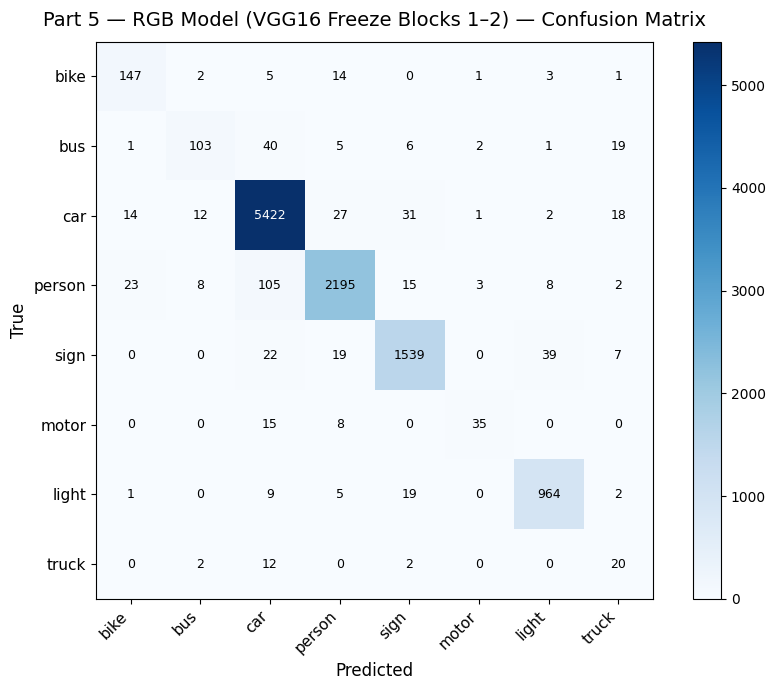

  Saved: confusion_matrix_rgb.png
  [2/4] IR confusion matrix...
  Plotting: Part 5 — IR Model (AE-4 + clf_reg_light) — Confusi...


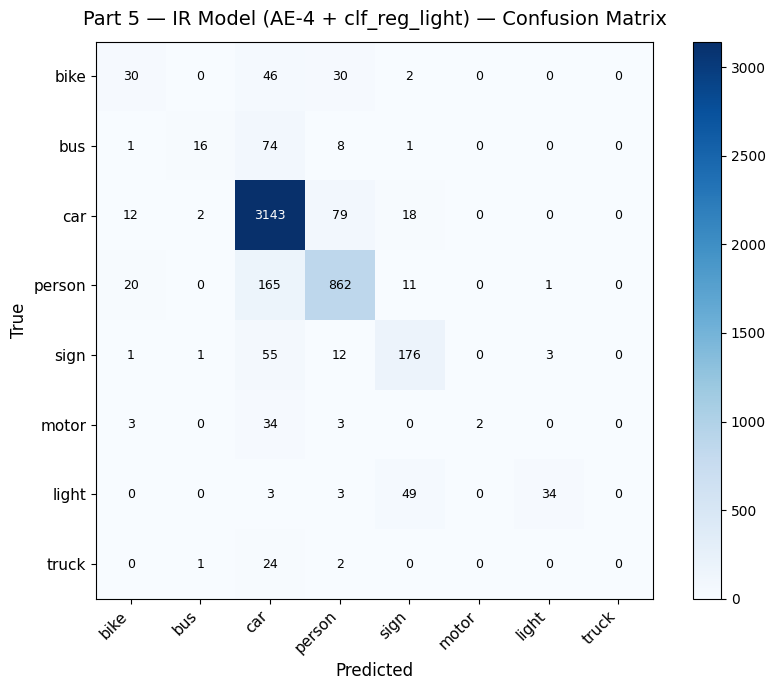

  Saved: confusion_matrix_ir.png
  [3/4] RGB classification report...
              precision    recall  f1-score   support

        bike       0.79      0.85      0.82       173
         bus       0.81      0.58      0.68       177
         car       0.96      0.98      0.97      5527
      person       0.97      0.93      0.95      2359
        sign       0.95      0.95      0.95      1626
       motor       0.83      0.60      0.70        58
       light       0.95      0.96      0.96      1000
       truck       0.29      0.56      0.38        36

    accuracy                           0.95     10956
   macro avg       0.82      0.80      0.80     10956
weighted avg       0.95      0.95      0.95     10956

  Saved: rgb_classification_report.csv
  [4/4] IR classification report...
              precision    recall  f1-score   support

        bike       0.45      0.28      0.34       108
         bus       0.80      0.16      0.27       100
         car       0.89      0.97      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [44]:
print("=" * 60)
print("CELL 9/12 — Part 5: Confusion matrices + classification reports")

def plot_confusion_matrix(y_true, y_pred, title, save_path):
    print(f"  Plotting: {title[:50]}...")
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(CLASS_NAMES, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)
    for ii in range(cm.shape[0]):
        for jj in range(cm.shape[1]):
            color = 'white' if cm[ii,jj] > cm.max()*0.6 else 'black'
            ax.text(jj, ii, str(int(cm[ii,jj])), ha='center', va='center', fontsize=9, color=color)
    fig.colorbar(im, ax=ax); fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f"  Saved: {save_path.name}")
    return cm

print("  [1/4] RGB confusion matrix...")
cm_rgb = plot_confusion_matrix(rgb_df.true_idx, rgb_df.pred_idx,
    'Part 5 — RGB Model (VGG16 Freeze Blocks 1–2) — Confusion Matrix',
    PART5_ROOT / 'confusion_matrix_rgb.png')

print("  [2/4] IR confusion matrix...")
cm_ir = plot_confusion_matrix(ir_df.true_idx, ir_df.pred_idx,
    'Part 5 — IR Model (AE-4 + clf_reg_light) — Confusion Matrix',
    PART5_ROOT / 'confusion_matrix_ir.png')

print("  [3/4] RGB classification report...")
rgb_report = classification_report(rgb_df.true_idx, rgb_df.pred_idx,
                                   target_names=CLASS_NAMES, output_dict=True)
print(classification_report(rgb_df.true_idx, rgb_df.pred_idx, target_names=CLASS_NAMES))
pd.DataFrame(rgb_report).T.to_csv(PART5_ROOT / 'rgb_classification_report.csv')
print("  Saved: rgb_classification_report.csv")

print("  [4/4] IR classification report...")
ir_report = classification_report(ir_df.true_idx, ir_df.pred_idx,
                                  target_names=CLASS_NAMES, output_dict=True)
print(classification_report(ir_df.true_idx, ir_df.pred_idx, target_names=CLASS_NAMES))
pd.DataFrame(ir_report).T.to_csv(PART5_ROOT / 'ir_classification_report.csv')
print("  Saved: ir_classification_report.csv")
print("=" * 60)


## 5.3 Classification Reports

## 5.4 Misclassified Samples — At Least 2 Per Class

## 5.5 Per-Class F1 Comparison: RGB vs IR

CELL 10/12 — Part 5: Misclassified grids + F1 comparison + cross-sensor analysis
  [1/7] RGB misclassified grid...


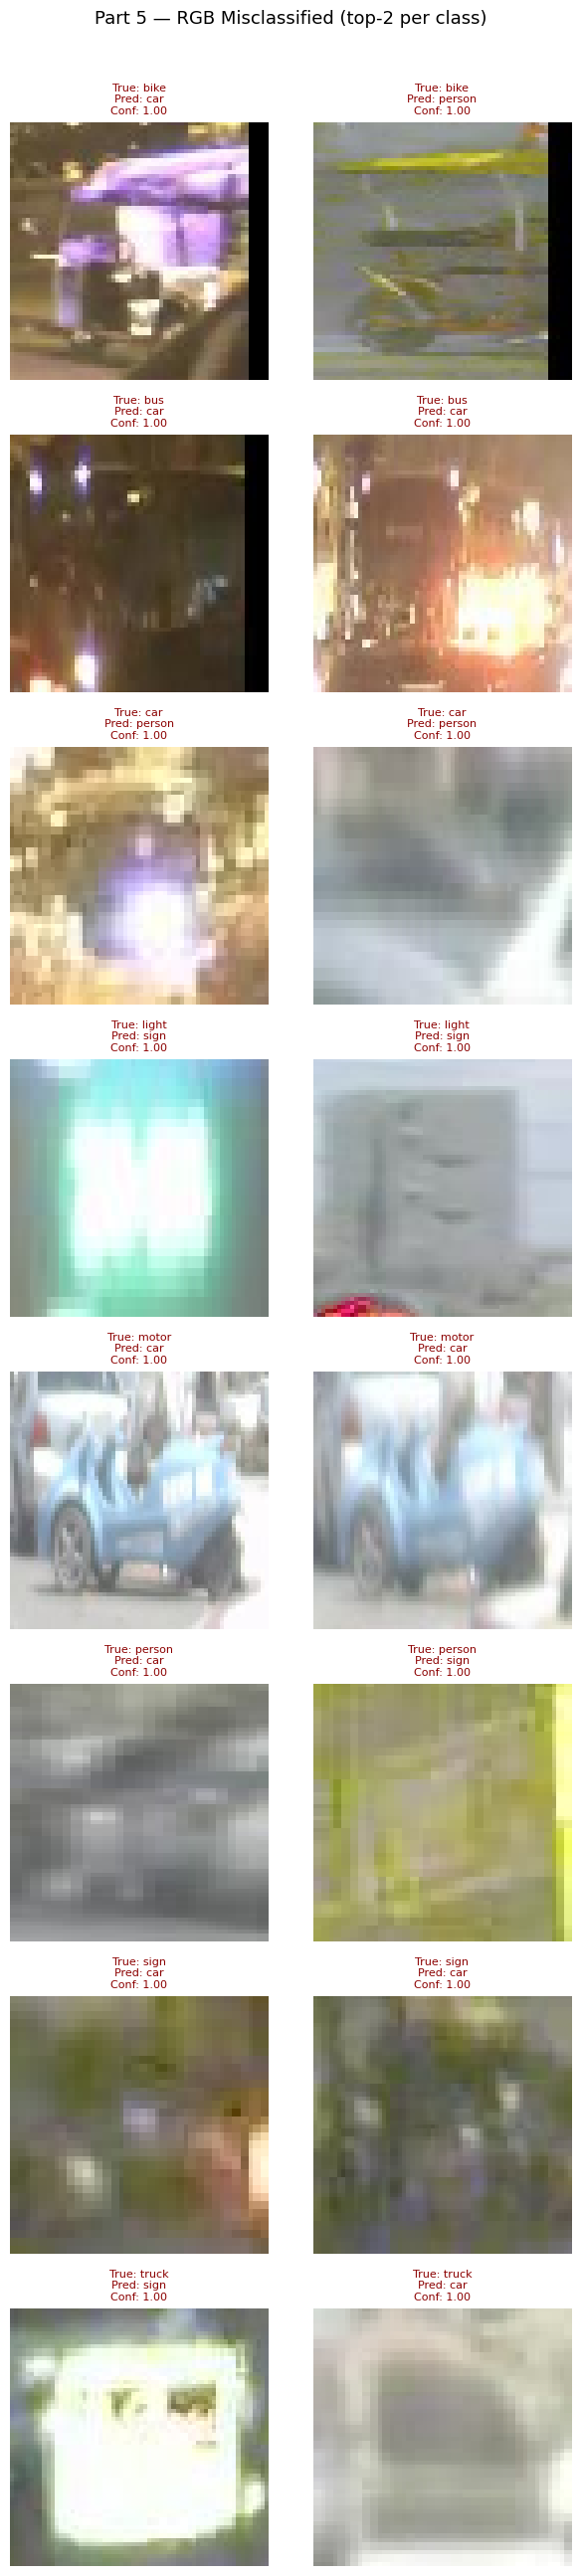

  Saved: misclassified_rgb.png  (16 samples shown)
  [2/7] IR misclassified grid...


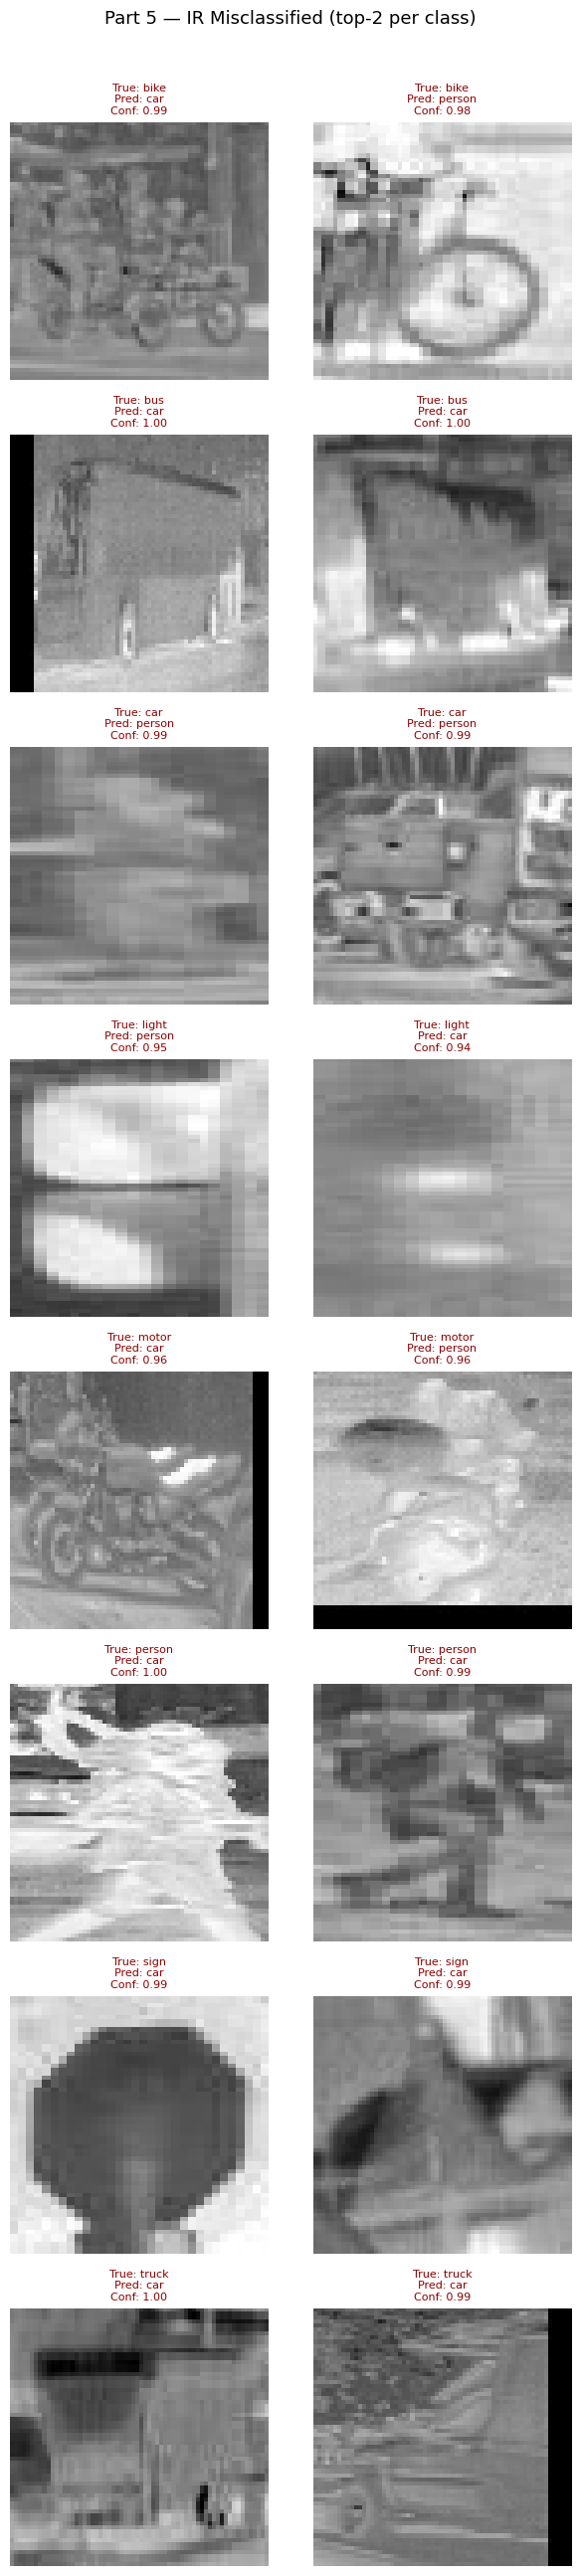

  Saved: misclassified_ir.png  (16 samples shown)
  [3/7] Per-class F1 comparison...
 class   rgb_f1    ir_f1  diff_rgb_minus_ir
  bike 0.818942 0.342857           0.476084
   bus 0.677632 0.266667           0.410965
   car 0.971946 0.924684           0.047262
person 0.947755 0.837707           0.110048
  sign 0.950587 0.697030           0.253557
 motor 0.700000 0.090909           0.609091
 light 0.955875 0.535433           0.420442
 truck 0.380952 0.000000           0.380952


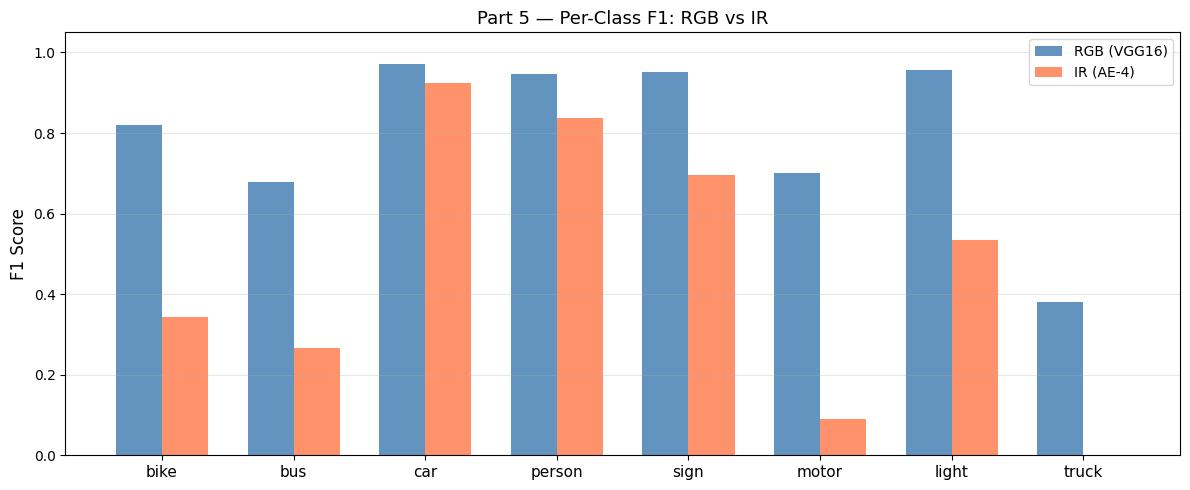

  Saved: per_class_f1_comparison.png + .csv
  [4/7] Cross-sensor merge by frame number...
  Matched frame+class pairs : 1,440
  Both correct              : 1,215  (84.4%)
  RGB wins                  : 182  (12.6%)
  IR  wins                  : 11  (0.8%)
  Both wrong                : 32  (2.2%)
  Saved: rgb_ir_comparison.csv
  [5/7] Cross-sensor sample visualisation...


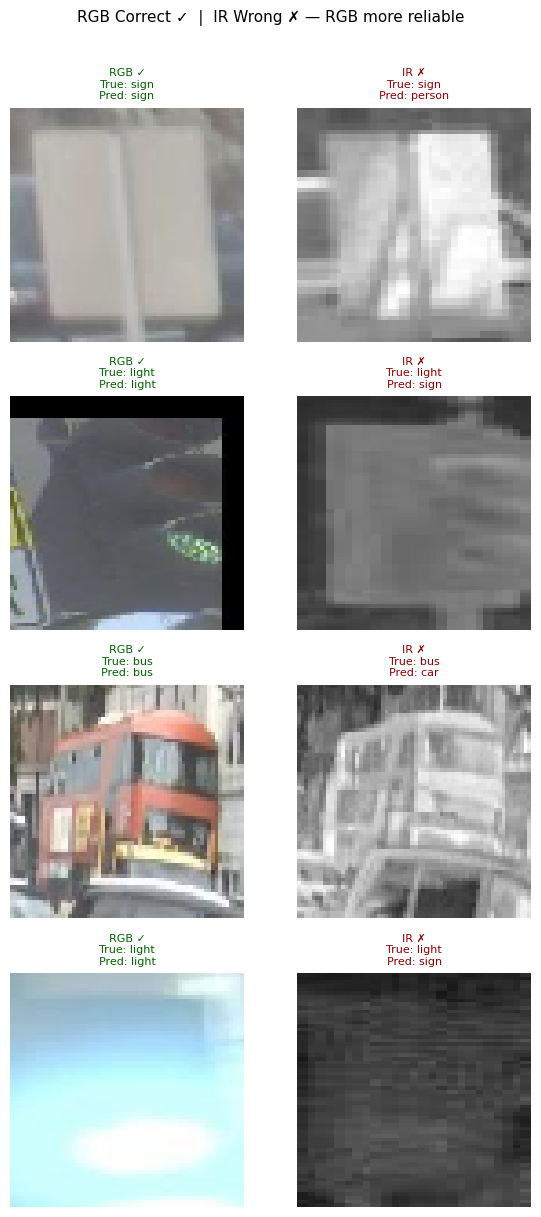

  Saved: cross_sensor_rgb_correct_ir_wrong.png


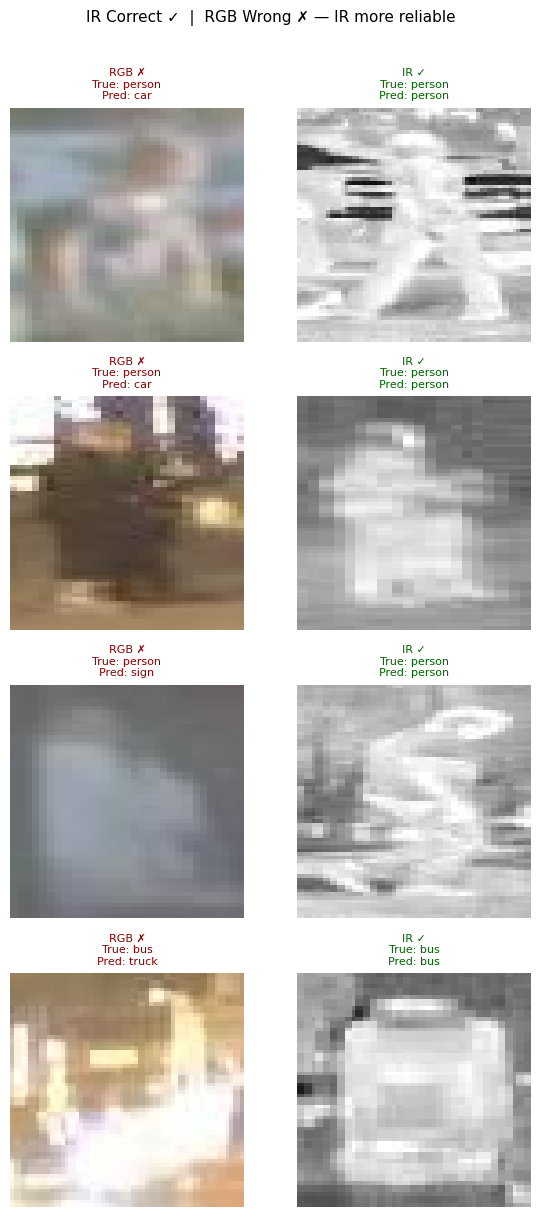

  Saved: cross_sensor_ir_correct_rgb_wrong.png
  [6/7] Per-class cross-sensor breakdown...
  Class     Total  BothOK  RGB✓IR✗  IR✓RGB✗  BothX
  ------------------------------------------------
  bike         49      18       30        0      1
  bus          56       8       30        1     17
  car         747     745        2        0      0
  person      346     306       31        9      0
  sign        157     117       39        0      1
  motor        27       1       16        0     10
  light        50      20       29        1      0
  truck         8       0        5        0      3
  [7/7] Sensor advantage chart...


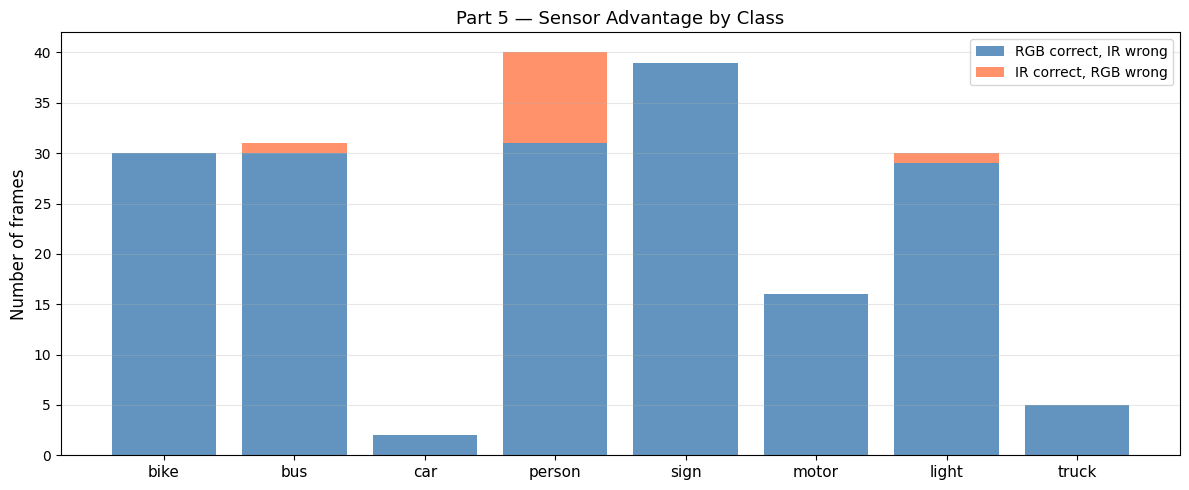

  Saved: sensor_advantage_by_class.png + cross_sensor_per_class.csv


In [53]:
print("=" * 60)
print("CELL 10/12 — Part 5: Misclassified grids + F1 comparison + cross-sensor analysis")

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

# ── [1/7] RGB misclassified grid ─────────────────────────────────────────────
print("  [1/7] RGB misclassified grid...")

def plot_misclassified_grid(pred_df, modality, save_path, n_per_class=2):
    mis = pred_df[~pred_df.correct].copy()
    selected = (mis.sort_values('confidence', ascending=False)
                   .groupby('true_label').head(n_per_class)
                   .sort_values('true_label'))
    classes_present = sorted(selected.true_label.unique())
    n_rows, n_cols = len(classes_present), n_per_class
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.2, n_rows*3.2))
    axes = np.array(axes).reshape(n_rows, n_cols)
    for r, cls in enumerate(classes_present):
        cls_rows = selected[selected.true_label == cls].reset_index(drop=True)
        for c in range(n_cols):
            ax = axes[r, c]; ax.axis('off')
            if c < len(cls_rows):
                row = cls_rows.iloc[c]
                ax.imshow(tf.keras.utils.load_img(row.path, target_size=IMAGE_SIZE))
                ax.set_title(f'True: {row.true_label}\nPred: {row.pred_label}\nConf: {row.confidence:.2f}',
                             fontsize=8, color='darkred')
            else:
                ax.text(0.5, 0.5, 'No sample', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')
    fig.suptitle(f'Part 5 — {modality.upper()} Misclassified (top-{n_per_class} per class)',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)
    return selected

rgb_mis = plot_misclassified_grid(rgb_df, 'RGB', PART5_ROOT / 'misclassified_rgb.png')
print(f"  Saved: misclassified_rgb.png  ({len(rgb_mis)} samples shown)")

# ── [2/7] IR misclassified grid ──────────────────────────────────────────────
print("  [2/7] IR misclassified grid...")
ir_mis = plot_misclassified_grid(ir_df, 'IR', PART5_ROOT / 'misclassified_ir.png')
print(f"  Saved: misclassified_ir.png  ({len(ir_mis)} samples shown)")

# ── [3/7] Per-class F1 comparison ────────────────────────────────────────────
print("  [3/7] Per-class F1 comparison...")
rgb_f1_per_class = f1_score(rgb_df.true_idx, rgb_df.pred_idx, average=None, labels=list(range(NUM_CLASSES)))
ir_f1_per_class  = f1_score(ir_df.true_idx,  ir_df.pred_idx,  average=None, labels=list(range(NUM_CLASSES)))

comparison_df = pd.DataFrame({
    'class':             CLASS_NAMES,
    'rgb_f1':            rgb_f1_per_class,
    'ir_f1':             ir_f1_per_class,
    'diff_rgb_minus_ir': rgb_f1_per_class - ir_f1_per_class,
})
comparison_df.to_csv(PART5_ROOT / 'per_class_f1_comparison.csv', index=False)
print(comparison_df.to_string(index=False))

x = np.arange(NUM_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-w/2, rgb_f1_per_class, w, label='RGB (VGG16)', color='steelblue', alpha=0.85)
ax.bar(x+w/2, ir_f1_per_class,  w, label='IR (AE-4)',   color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Part 5 — Per-Class F1: RGB vs IR', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(PART5_ROOT / 'per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print("  Saved: per_class_f1_comparison.png + .csv")

# ── [4/7] Cross-sensor merge by frame number ──────────────────────────────────
print("  [4/7] Cross-sensor merge by frame number...")

def extract_frame_num(filename):
    parts = filename.replace('.jpg', '').split('-')
    try:
        return parts[parts.index('frame') + 1]
    except (ValueError, IndexError):
        return None

rgb_df['frame_num'] = rgb_df['file_name'].apply(extract_frame_num)
ir_df['frame_num']  = ir_df['file_name'].apply(extract_frame_num)

rgb_agg = (rgb_df[['frame_num','true_label','pred_label','correct','confidence']]
           .rename(columns={'pred_label':'rgb_pred','correct':'rgb_correct','confidence':'rgb_conf'})
           .groupby(['frame_num','true_label'])
           .agg(rgb_correct=('rgb_correct','mean'),
                rgb_pred=('rgb_pred', lambda x: x.mode()[0]),
                rgb_conf=('rgb_conf','mean'))
           .reset_index())
rgb_agg['rgb_correct'] = rgb_agg['rgb_correct'] >= 0.5

ir_agg = (ir_df[['frame_num','true_label','pred_label','correct','confidence']]
          .rename(columns={'pred_label':'ir_pred','correct':'ir_correct','confidence':'ir_conf'})
          .groupby(['frame_num','true_label'])
          .agg(ir_correct=('ir_correct','mean'),
               ir_pred=('ir_pred', lambda x: x.mode()[0]),
               ir_conf=('ir_conf','mean'))
          .reset_index())
ir_agg['ir_correct'] = ir_agg['ir_correct'] >= 0.5

merged = rgb_agg.merge(ir_agg, on=['frame_num','true_label'], how='inner')
merged.to_csv(ANALYSIS_ROOT / 'rgb_ir_comparison.csv', index=False)

rgb_only_correct = merged[ merged.rgb_correct & ~merged.ir_correct]
ir_only_correct  = merged[~merged.rgb_correct &  merged.ir_correct]
both_wrong       = merged[~merged.rgb_correct & ~merged.ir_correct]
both_correct     = merged[ merged.rgb_correct &  merged.ir_correct]

print(f"  Matched frame+class pairs : {len(merged):,}")
print(f"  Both correct              : {len(both_correct):,}  ({len(both_correct)/len(merged)*100:.1f}%)")
print(f"  RGB wins                  : {len(rgb_only_correct):,}  ({len(rgb_only_correct)/len(merged)*100:.1f}%)")
print(f"  IR  wins                  : {len(ir_only_correct):,}  ({len(ir_only_correct)/len(merged)*100:.1f}%)")
print(f"  Both wrong                : {len(both_wrong):,}  ({len(both_wrong)/len(merged)*100:.1f}%)")
print("  Saved: rgb_ir_comparison.csv")

# ── [5/7] Cross-sensor sample visualisation ───────────────────────────────────
print("  [5/7] Cross-sensor sample visualisation...")

def plot_cross_sensor_samples(subset_df, title, save_path, n=4):
    if len(subset_df) == 0:
        print(f"    No samples for: {title}"); return
    sample = subset_df.sample(min(n, len(subset_df)), random_state=SEED)
    fig, axes = plt.subplots(len(sample), 2, figsize=(6, len(sample)*3))
    axes = np.array(axes).reshape(len(sample), 2)
    for i, (_, row) in enumerate(sample.iterrows()):
        rgb_match = rgb_df[(rgb_df.frame_num == row.frame_num) &
                           (rgb_df.true_label == row.true_label)].iloc[0]
        ir_match  = ir_df[(ir_df.frame_num  == row.frame_num) &
                          (ir_df.true_label  == row.true_label)].iloc[0]
        for ax, match, sensor in zip(axes[i], [rgb_match, ir_match], ['RGB', 'IR']):
            ax.imshow(tf.keras.utils.load_img(match.path, target_size=IMAGE_SIZE))
            ok = match.correct
            ax.set_title(f'{sensor} {"✓" if ok else "✗"}\nTrue: {row.true_label}\nPred: {match.pred_label}',
                         fontsize=8, color=('darkgreen' if ok else 'darkred'))
            ax.axis('off')
    fig.suptitle(title, fontsize=11, y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

plot_cross_sensor_samples(rgb_only_correct,
    'RGB Correct ✓  |  IR Wrong ✗ — RGB more reliable',
    PART5_ROOT / 'cross_sensor_rgb_correct_ir_wrong.png')
print("  Saved: cross_sensor_rgb_correct_ir_wrong.png")

plot_cross_sensor_samples(ir_only_correct,
    'IR Correct ✓  |  RGB Wrong ✗ — IR more reliable',
    PART5_ROOT / 'cross_sensor_ir_correct_rgb_wrong.png')
print("  Saved: cross_sensor_ir_correct_rgb_wrong.png")

# ── [6/7] Per-class cross-sensor breakdown table ──────────────────────────────
print("  [6/7] Per-class cross-sensor breakdown...")
cross_df = pd.DataFrame([{
    'class':        cls,
    'total':        len(merged[merged.true_label==cls]),
    'both_correct': (merged[merged.true_label==cls].rgb_correct &  merged[merged.true_label==cls].ir_correct).sum(),
    'rgb_wins':     (merged[merged.true_label==cls].rgb_correct & ~merged[merged.true_label==cls].ir_correct).sum(),
    'ir_wins':      (~merged[merged.true_label==cls].rgb_correct &  merged[merged.true_label==cls].ir_correct).sum(),
    'both_wrong':   (~merged[merged.true_label==cls].rgb_correct & ~merged[merged.true_label==cls].ir_correct).sum(),
} for cls in CLASS_NAMES])
cross_df.to_csv(PART5_ROOT / 'cross_sensor_per_class.csv', index=False)

print(f"  {'Class':<8} {'Total':>6} {'BothOK':>7} {'RGB✓IR✗':>8} {'IR✓RGB✗':>8} {'BothX':>6}")
print("  " + "-" * 48)
for _, row in cross_df.iterrows():
    print(f"  {row['class']:<8} {row['total']:>6} {row['both_correct']:>7} {row['rgb_wins']:>8} {row['ir_wins']:>8} {row['both_wrong']:>6}")

# ── [7/7] Sensor advantage bar chart ─────────────────────────────────────────
print("  [7/7] Sensor advantage chart...")
x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, cross_df.rgb_wins, label='RGB correct, IR wrong', color='steelblue', alpha=0.85)
ax.bar(x, cross_df.ir_wins, bottom=cross_df.rgb_wins,
       label='IR correct, RGB wrong', color='coral', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Number of frames', fontsize=12)
ax.set_title('Part 5 — Sensor Advantage by Class', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(PART5_ROOT / 'sensor_advantage_by_class.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print("  Saved: sensor_advantage_by_class.png + cross_sensor_per_class.csv")
print("=" * 60)

## 5.8 Written Analysis

In [54]:
print("=" * 60)
print("CELL 11/12 — Part 5: Written analysis")

rgb_macro_f1 = float(f1_score(rgb_df.true_idx, rgb_df.pred_idx, average='macro'))
ir_macro_f1  = float(f1_score(ir_df.true_idx,  ir_df.pred_idx,  average='macro'))
rgb_acc = rgb_df.correct.mean()
ir_acc  = ir_df.correct.mean()
rgb_better_classes = comparison_df[comparison_df.diff_rgb_minus_ir >  0.05].sort_values('diff_rgb_minus_ir', ascending=False)
ir_better_classes  = comparison_df[comparison_df.diff_rgb_minus_ir < -0.05].sort_values('diff_rgb_minus_ir')

analysis = f"""
PART 5 — ANALYSIS SUMMARY
==========================
Overall Performance:
  RGB (VGG16, freeze blocks 1-2): Accuracy={rgb_acc:.4f}, Macro F1={rgb_macro_f1:.4f}
  IR  (AE-4 + clf_reg_light):     Accuracy={ir_acc:.4f},  Macro F1={ir_macro_f1:.4f}

Cross-Sensor Breakdown (matched pairs={len(merged):,}):
  Both correct  : {len(both_correct):,} ({len(both_correct)/len(merged)*100:.1f}%)
  RGB wins      : {len(rgb_only_correct):,} ({len(rgb_only_correct)/len(merged)*100:.1f}%)
  IR  wins      : {len(ir_only_correct):,} ({len(ir_only_correct)/len(merged)*100:.1f}%)
  Both wrong    : {len(both_wrong):,} ({len(both_wrong)/len(merged)*100:.1f}%)

Classes where RGB is more reliable (F1 diff > 0.05):
{"".join([f"  {r['class']:8s}: RGB F1={r['rgb_f1']:.3f}, IR F1={r['ir_f1']:.3f}  (diff={r['diff_rgb_minus_ir']:+.3f})" + chr(10) for _, r in rgb_better_classes.iterrows()])}
Classes where IR is more reliable (F1 diff < -0.05):
{"".join([f"  {r['class']:8s}: RGB F1={r['rgb_f1']:.3f}, IR F1={r['ir_f1']:.3f}  (diff={r['diff_rgb_minus_ir']:+.3f})" + chr(10) for _, r in ir_better_classes.iterrows()])}
General Sensor Reliability Scenarios:
  - RGB generally more reliable: VGG16 pretrained on ImageNet provides strong color/texture priors.
  - IR better at night / low-light for heat-emitting objects (persons, buses, trucks).
  - RGB struggles when objects share appearance (motor vs bike) or lighting is poor.
  - IR struggles for objects with no thermal signature (signs, lights).
  - RGB vs IR F1 gap ({rgb_macro_f1:.3f} vs {ir_macro_f1:.3f}) is partly architectural: VGG16 is
    fine-tuned end-to-end; AE uses unsupervised reconstruction loss.
"""
print(analysis)
with open(PART5_ROOT / 'analysis_summary.txt', 'w') as f:
    f.write(analysis)
print("  Saved: analysis_summary.txt")
print("=" * 60)


CELL 11/12 — Part 5: Written analysis

PART 5 — ANALYSIS SUMMARY
Overall Performance:
  RGB (VGG16, freeze blocks 1-2): Accuracy=0.9515, Macro F1=0.8005
  IR  (AE-4 + clf_reg_light):     Accuracy=0.8652,  Macro F1=0.4619

Cross-Sensor Breakdown (matched pairs=1,440):
  Both correct  : 1,215 (84.4%)
  RGB wins      : 182 (12.6%)
  IR  wins      : 11 (0.8%)
  Both wrong    : 32 (2.2%)

Classes where RGB is more reliable (F1 diff > 0.05):
  motor   : RGB F1=0.700, IR F1=0.091  (diff=+0.609)
  bike    : RGB F1=0.819, IR F1=0.343  (diff=+0.476)
  light   : RGB F1=0.956, IR F1=0.535  (diff=+0.420)
  bus     : RGB F1=0.678, IR F1=0.267  (diff=+0.411)
  truck   : RGB F1=0.381, IR F1=0.000  (diff=+0.381)
  sign    : RGB F1=0.951, IR F1=0.697  (diff=+0.254)
  person  : RGB F1=0.948, IR F1=0.838  (diff=+0.110)

Classes where IR is more reliable (F1 diff < -0.05):

General Sensor Reliability Scenarios:
  - RGB generally more reliable: VGG16 pretrained on ImageNet provides strong color/texture prio

---
# Part 6 — Final Model Selection & Optimization for Blind Test

## 6.1 Rank All Experiments from Master Summary

In [55]:
print("=" * 60)
print("CELL 12/12 — Part 6: Model selection, final training & summary")
print()
print("  [1/4] Ranking experiments from master summary...")

if MASTER_SUMMARY_CSV.exists():
    master_df = pd.read_csv(MASTER_SUMMARY_CSV)
    print(f"  Loaded master summary: {master_df.shape[0]} experiments, {master_df.shape[1]} columns")
    print(f"  Parts found: {master_df['part'].unique().tolist()}")
    ranked = master_df.sort_values(
        by=['modality','final_val_f1','final_val_acc','total_params'],
        ascending=[True, False, False, True])
    best_per_modality = ranked.groupby('modality', as_index=False).first()
    best_per_modality.to_csv(PART6_ROOT / 'best_per_modality.csv', index=False)
    print()
    print("  Best per modality from master summary:")
    print(best_per_modality[['modality','experiment','final_val_acc','final_val_f1','total_params']].to_string(index=False))
else:
    print("  master_experiment_summary.csv not found — using known results from Parts 3 & 4.")
    best_per_modality = pd.DataFrame([
        {'modality': 'rgb', 'experiment': 'rgb_vgg16_freeze_blocks_1_to_2',
         'final_val_acc': 0.9700, 'final_val_f1': 0.8322, 'total_params': 14862984},
        {'modality': 'ir',  'experiment': 'ae_4__clf_reg_light',
         'final_val_acc': 0.8614, 'final_val_f1': 0.4205, 'total_params': 2114376},
    ])
    best_per_modality.to_csv(PART6_ROOT / 'best_per_modality.csv', index=False)
    print(best_per_modality.to_string(index=False))
print()


CELL 12/12 — Part 6: Model selection, final training & summary

  [1/4] Ranking experiments from master summary...
  Loaded master summary: 51 experiments, 23 columns
  Parts found: ['part1', 'part2_regularization', 'part2_dropout', 'part2_augmentation', 'part2_combined', 'part3', 'part4']

  Best per modality from master summary:
modality  experiment  final_val_acc  final_val_f1  total_params
      ir  ir_combo_1       0.951492      0.754608    25740296.0
     rgb rgb_combo_1       0.969332      0.832179    14862984.0



## 6.2 Final Optimized RGB Model
Takes the best Part 3 config and retrains with:
- More epochs (80)
- Lower LR (5e-5)
- Medium augmentation (was light)
- Slightly higher dropout (0.3 → 0.35)

  [2/4] Final RGB model (VGG16 freeze_blocks_1_to_2, optimized)...
  Loading RGB datasets...
Found 108297 files belonging to 8 classes.
Found 10956 files belonging to 8 classes.
  RGB datasets ready (108.4s)
  Training final optimized RGB model (80 epochs, lr=5e-5, aug=medium)...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/80
847/847 ━━━━━━━━━━━━━━━━━━━━ 177s 200ms/step - accuracy: 0.7462 - loss: 0.9619 - val_accuracy: 0.9472 - val_loss: 0.1976 - learning_rate: 5.0000e-05
Epoch 2/80
847/847 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.9284 - loss: 0.2674 - val_accuracy: 0.9387 - val_loss: 0.2005 - learning_rate: 5.0000e-05
Epoch 3/80
847/847 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9487 - loss: 0.1924 - val_accuracy: 0.9461 - val_loss: 0.1928 - learning_rate: 5.0000e-05
Epoch 4/80
847/847 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - accuracy: 0.9564 - loss: 0.1600 - val_accuracy: 0.9597 - val_loss: 0.1537 - learning_rate: 5.0000e-05
Epoch 5/80
847/847 ━━━━━━━━━━━━━━━

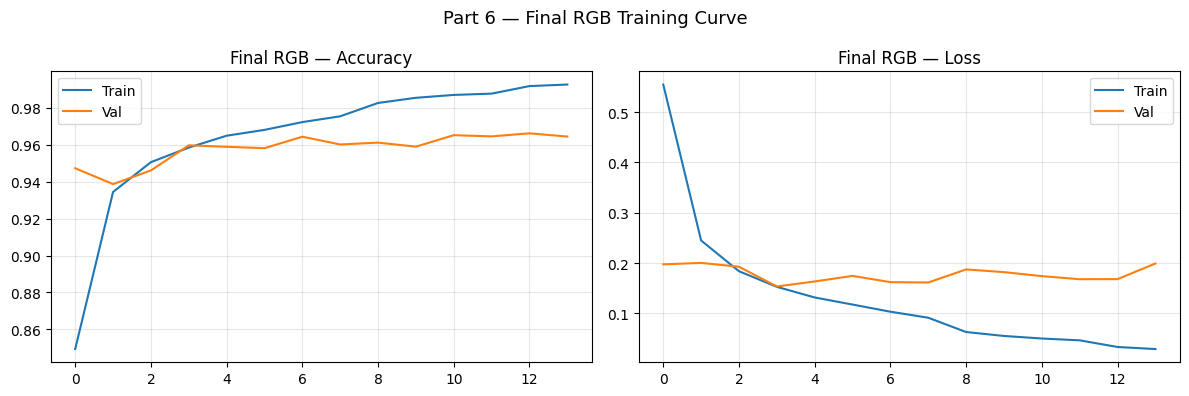

  Evaluating final RGB on val set...
  Done in 9.7s
  Final RGB — Val Accuracy: 0.9597  |  Macro F1: 0.8037



In [56]:
print("  [2/4] Final RGB model (VGG16 freeze_blocks_1_to_2, optimized)...")
FINAL_RGB_PATH = PART6_ROOT / 'final_rgb_model.keras'
train_rgb_ds, val_rgb_ds = load_modality('rgb')

if FINAL_RGB_PATH.exists():
    mb = FINAL_RGB_PATH.stat().st_size / 1024 / 1024
    print(f"  Loading existing final RGB model ({mb:.1f} MB)...")
    t0 = time.time()
    final_rgb_model = tf.keras.models.load_model(FINAL_RGB_PATH)
    print(f"  Loaded in {time.time()-t0:.1f}s")
else:
    print("  Training final optimized RGB model (80 epochs, lr=5e-5, aug=medium)...")
    final_rgb_model = build_vgg16_transfer(
        input_shape=(*IMAGE_SIZE, 3), freeze_option='freeze_blocks_1_to_2',
        dense_units=(256, 64), dropout=0.35, weight_decay=1e-5, augmentation_name='medium')
    history_final_rgb = compile_and_train(
        final_rgb_model, train_rgb_ds, val_rgb_ds,
        lr=5e-5, save_dir=PART6_ROOT / 'rgb_training', epochs=80)
    final_rgb_model.save(FINAL_RGB_PATH)
    print(f"  Saved to {FINAL_RGB_PATH}")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_final_rgb.history['accuracy'],     label='Train')
    axes[0].plot(history_final_rgb.history['val_accuracy'], label='Val')
    axes[0].set_title('Final RGB — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history_final_rgb.history['loss'],     label='Train')
    axes[1].plot(history_final_rgb.history['val_loss'], label='Val')
    axes[1].set_title('Final RGB — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.suptitle('Part 6 — Final RGB Training Curve', fontsize=13); fig.tight_layout()
    fig.savefig(PART6_ROOT / 'final_rgb_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

print("  Evaluating final RGB on val set...")
t0 = time.time()
y_true_rgb_f, y_pred_rgb_f, _ = evaluate_ds(final_rgb_model, val_rgb_ds)
final_rgb_f1  = f1_score(y_true_rgb_f, y_pred_rgb_f, average='macro')
final_rgb_acc = (y_true_rgb_f == y_pred_rgb_f).mean()
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Final RGB — Val Accuracy: {final_rgb_acc:.4f}  |  Macro F1: {final_rgb_f1:.4f}")
print()


## 6.3 Final Optimized IR Model
Retrains AE-4 with more epochs and a slightly tuned classifier.

  [3/4] Final IR model (AE-4 + clf_reg_light, optimized)...
  Loading IR datasets...
Found 52930 files belonging to 8 classes.
Found 4927 files belonging to 8 classes.
  IR datasets ready (47.2s)
  Training final IR model (AE-4, 80 epochs, lr=5e-4)...
  [a] Training autoencoder...
Cause: could not parse the source code of <function <lambda> at 0x7f388cda5a80>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x, y: (x, x)

Match 1:
lambda x, y: (x, x)

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7f388cda5a80>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Ma

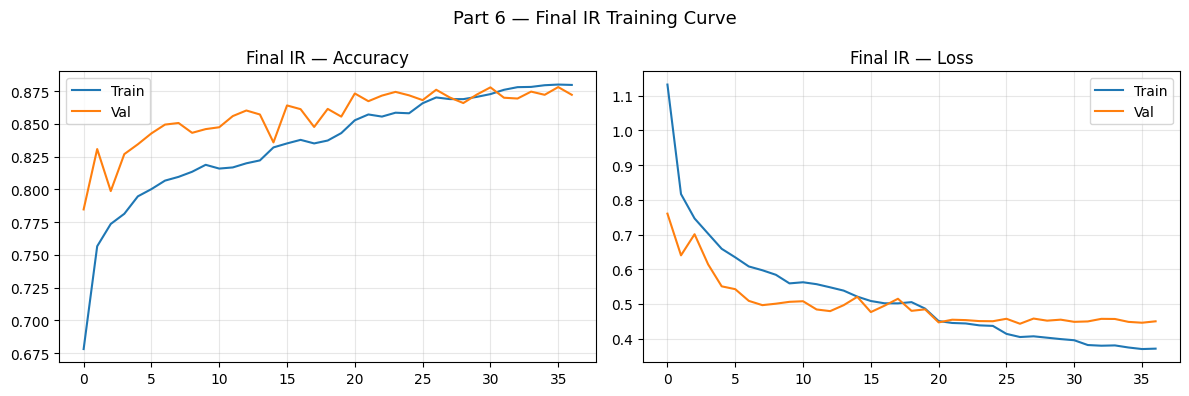

  Evaluating final IR on val set...
  Done in 4.2s
  Final IR — Val Accuracy: 0.8760  |  Macro F1: 0.5256



In [57]:
print("  [3/4] Final IR model (AE-4 + clf_reg_light, optimized)...")
FINAL_IR_ENC_PATH = PART6_ROOT / 'final_ir_encoder.keras'
FINAL_IR_CLF_PATH = PART6_ROOT / 'final_ir_classifier.keras'
train_ir_ds, val_ir_ds = load_modality('ir')

if FINAL_IR_ENC_PATH.exists() and FINAL_IR_CLF_PATH.exists():
    enc_mb = FINAL_IR_ENC_PATH.stat().st_size / 1024 / 1024
    clf_mb = FINAL_IR_CLF_PATH.stat().st_size / 1024 / 1024
    print(f"  Loading encoder ({enc_mb:.1f} MB) + classifier ({clf_mb:.1f} MB)...")
    t0 = time.time()
    final_ir_encoder    = tf.keras.models.load_model(FINAL_IR_ENC_PATH)
    final_ir_classifier = tf.keras.models.load_model(FINAL_IR_CLF_PATH)
    print(f"  Loaded in {time.time()-t0:.1f}s")
else:
    print("  Training final IR model (AE-4, 80 epochs, lr=5e-4)...")
    final_ir_encoder, _, ae = build_encoder_decoder(
        input_shape=(*IMAGE_SIZE, 3), encoder_filters=[32, 64],
        latent_channels=32, weight_decay=1e-5)
    ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    print("  [a] Training autoencoder...")
    ae.fit(train_ir_ds.map(lambda x,y:(x,x)), validation_data=val_ir_ds.map(lambda x,y:(x,x)),
           epochs=80, callbacks=get_callbacks(PART6_ROOT/'ae_training'), verbose=1)
    final_ir_encoder.save(FINAL_IR_ENC_PATH)
    print(f"  Encoder saved.")
    print("  [b] Extracting features...")
    def _ext(enc, ds):
        X, Y = [], []
        for k, (xb, yb) in enumerate(ds):
            X.append(enc.predict(xb, verbose=0)); Y.append(yb.numpy())
            if (k+1) % 20 == 0: print(f"    batch {k+1}")
        return np.concatenate(X), np.concatenate(Y)
    xtr, ytr = _ext(final_ir_encoder, train_ir_ds)
    xvl, yvl = _ext(final_ir_encoder, val_ir_ds)
    print(f"  Features: train {xtr.shape}, val {xvl.shape}")
    print("  [c] Training classifier...")
    final_ir_classifier = build_feature_classifier(
        feature_shape=xtr.shape[1:], dense_units=(256,64), dropout=0.3, weight_decay=1e-4)
    final_ir_classifier.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
        loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_ir = final_ir_classifier.fit(xtr, ytr, validation_data=(xvl, yvl),
        epochs=80, batch_size=BATCH_SIZE,
        callbacks=get_callbacks(PART6_ROOT/'clf_training'), verbose=1)
    final_ir_classifier.save(FINAL_IR_CLF_PATH)
    print(f"  Classifier saved.")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist_ir.history['accuracy'], label='Train')
    axes[0].plot(hist_ir.history['val_accuracy'], label='Val')
    axes[0].set_title('Final IR — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist_ir.history['loss'], label='Train')
    axes[1].plot(hist_ir.history['val_loss'], label='Val')
    axes[1].set_title('Final IR — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    fig.suptitle('Part 6 — Final IR Training Curve', fontsize=13); fig.tight_layout()
    fig.savefig(PART6_ROOT/'final_ir_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close(fig)

print("  Evaluating final IR on val set...")
t0 = time.time()
xvl_e, yvl_e = [], []
for xb, yb in val_ir_ds:
    xvl_e.append(final_ir_encoder.predict(xb, verbose=0)); yvl_e.append(yb.numpy())
xvl_e = np.concatenate(xvl_e); yvl_e = np.concatenate(yvl_e)
y_pred_ir_f = np.argmax(final_ir_classifier.predict(xvl_e, verbose=0), axis=1)
final_ir_f1  = f1_score(yvl_e, y_pred_ir_f, average='macro')
final_ir_acc = (yvl_e == y_pred_ir_f).mean()
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Final IR — Val Accuracy: {final_ir_acc:.4f}  |  Macro F1: {final_ir_f1:.4f}")
print()


## 6.4 Summary Table & Reasoning

In [59]:
print("  [4/4] Saving summary & reasoning...")
summary_p6 = pd.DataFrame([
    {'modality':'RGB', 'base_model':'VGG16 (ImageNet)', 'freeze_strategy':'freeze_blocks_1_to_2',
     'dense_units':'256→64', 'dropout':0.35, 'weight_decay':1e-5, 'augmentation':'medium',
     'lr':5e-5, 'max_epochs':80, 'part3_val_f1':0.8322,
     'final_val_f1':final_rgb_f1, 'final_val_acc':final_rgb_acc, 'improvement':final_rgb_f1-0.8322},
    {'modality':'IR',  'base_model':'ConvAE AE-4 (filters=[32,64], latent=32)',
     'freeze_strategy':'N/A', 'dense_units':'256→64', 'dropout':0.3, 'weight_decay':1e-4,
     'augmentation':'none', 'lr':5e-4, 'max_epochs':80, 'part4_val_f1':0.4205,
     'final_val_f1':final_ir_f1, 'final_val_acc':final_ir_acc, 'improvement':final_ir_f1-0.4205},
])
summary_p6.to_csv(PART6_ROOT / 'final_model_summary.csv', index=False)

reasoning = {
    'rgb': {'selected':'VGG16 freeze_blocks_1_to_2',
             'reason':('Best val F1 (0.8322) in Part 1–3. Blocks 3–5 fine-tuned to FLIR ADAS domain. '
                       'Final: medium aug, dropout=0.35, lr=5e-5 for stable convergence.')},
    'ir':  {'selected':'AE-4 + clf_reg_light',
             'reason':('Best val F1 (0.4205) among 12 Part 4 options. latent=32 preserves discriminative info. '
                       'clf_reg_light outperforms strong variant by avg 0.124 F1. '
                       'Final: 80 epochs, lr=5e-4.')},
}
with open(PART6_ROOT / 'reasoning.json', 'w') as f:
    json.dump(reasoning, f, indent=2)

print()
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  {'Modality':<8} {'Val Acc':>9} {'Val F1':>8} {'vs baseline':>12}")
print("  " + "-" * 42)
for _, row in summary_p6.iterrows():
    base_key = 'part3_val_f1' if row['modality']=='RGB' else 'part4_val_f1'
    print(f"  {row['modality']:<8} {row['final_val_acc']*100:>8.2f}% {row['final_val_f1']:>8.4f} {row['improvement']:>+11.4f}")
print()
print("  All outputs saved. Listing Part 5 & 6 files:")
for root in [PART5_ROOT, PART6_ROOT]:
    part = root.name
    for f in sorted(root.rglob('*')):
        if f.is_file():
            print(f"  {part}/{f.relative_to(root)}  ({f.stat().st_size/1024:.1f} KB)")
print()
print("=" * 60)
print("NOTEBOOK COMPLETE.")
print("=" * 60)


  [4/4] Saving summary & reasoning...

FINAL RESULTS SUMMARY
  Modality   Val Acc   Val F1  vs baseline
  ------------------------------------------
  RGB         95.97%   0.8037     -0.0285
  IR          87.60%   0.5256     +0.1051

  All outputs saved. Listing Part 5 & 6 files:
  part5_analysis/analysis_summary.txt  (1.3 KB)
  part5_analysis/confusion_matrix_ir.png  (78.3 KB)
  part5_analysis/confusion_matrix_rgb.png  (85.2 KB)
  part5_analysis/cross_sensor_ir_correct_rgb_wrong.png  (108.1 KB)
  part5_analysis/cross_sensor_per_class.csv  (0.2 KB)
  part5_analysis/cross_sensor_rgb_correct_ir_wrong.png  (118.6 KB)
  part5_analysis/ir_classification_report.csv  (0.7 KB)
  part5_analysis/ir_predictions.csv  (1195.4 KB)
  part5_analysis/misclassified_ir.png  (196.9 KB)
  part5_analysis/misclassified_rgb.png  (227.1 KB)
  part5_analysis/per_class_f1_comparison.csv  (0.5 KB)
  part5_analysis/per_class_f1_comparison.png  (37.8 KB)
  part5_analysis/rgb_classification_report.csv  (0.8 KB)
  pa

## 6.5 Final Output Directory Summary

---
## Final Submission — Load & Test Models
Run this section to prepare both models for the TA's test code.

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
from pathlib import Path

# ── Update this path to where your 3 model files are ─────────────────────────
MODEL_DIR = Path('/kaggle/input/<your-dataset-name>/final model')

# ── Load RGB model ────────────────────────────────────────────────────────────
print("Loading RGB model...")
rgb_model = tf.keras.models.load_model(MODEL_DIR / 'freeze_blocks_1_to_2.keras')
print(f"  input: {rgb_model.input_shape}  output: {rgb_model.output_shape}")

# ── Load IR encoder + classifier ─────────────────────────────────────────────
print("Loading AE...")
full_ae = tf.keras.models.load_model(MODEL_DIR / 'ae4best.keras')
print("Loading IR classifier...")
ir_classifier = tf.keras.models.load_model(MODEL_DIR / 'retrained_best.keras')

# Extract encoder submodel
ir_encoder = None
for layer in full_ae.layers:
    if isinstance(layer, tf.keras.Model) and 'encoder' in layer.name.lower():
        ir_encoder = layer
        break
if ir_encoder is None:
    ir_encoder = tf.keras.Model(
        inputs=full_ae.input,
        outputs=full_ae.get_layer('latent_conv').output,
        name='encoder'
    )
print(f"  Encoder output: {ir_encoder.output_shape}")

# ── Wrap IR into single model ─────────────────────────────────────────────────
ir_input    = tf.keras.Input(shape=(64, 64, 3), name='ir_input')
ir_features = ir_encoder(ir_input)
ir_output   = ir_classifier(ir_features)
ir_model    = tf.keras.Model(inputs=ir_input, outputs=ir_output, name='ir_final')
print(f"  IR model input: {ir_model.input_shape}  output: {ir_model.output_shape}")

# ── Save final models ─────────────────────────────────────────────────────────
rgb_model.save('/kaggle/working/final_rgb_model.keras')
ir_model.save('/kaggle/working/final_ir_model.keras')
print("\nSaved:")
print("  /kaggle/working/final_rgb_model.keras")
print("  /kaggle/working/final_ir_model.keras")


## TA Test Code — RGB

In [ ]:
# ── RGB Test (TA format) ──────────────────────────────────────────────────────
model = tf.keras.models.load_model('/kaggle/working/final_rgb_model.keras')

image_folder = ''           # ← TA will fill this
image_csv    = 'rgb_image_names.csv'   # ← TA will fill this

image_names = pd.read_csv(image_csv, header=None)[0].tolist()
image_paths = [os.path.join(image_folder, name) for name in image_names]

dataset = tf.data.Dataset.from_tensor_slices(image_paths)

def process_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = tf.cast(img, tf.float32) / 255.0
    return img

dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

predictions = []
for images in dataset:
    preds = model.predict(images, verbose=0)
    preds = tf.argmax(preds, axis=1).numpy().tolist()
    predictions.extend(preds)

predictions_df = pd.DataFrame(predictions, columns=['predictions'])
predictions_df.to_csv('rgb_predictions.csv', index=False)
print(f"RGB done — {len(predictions)} predictions saved.")
print(f"Sample (integers): {predictions[:5]}")


## TA Test Code — IR

In [ ]:
# ── IR Test (TA format) ───────────────────────────────────────────────────────
model = tf.keras.models.load_model('/kaggle/working/final_ir_model.keras')

image_folder = ''           # ← TA will fill this
image_csv    = 'ir_image_names.csv'    # ← TA will fill this

image_names = pd.read_csv(image_csv, header=None)[0].tolist()
image_paths = [os.path.join(image_folder, name) for name in image_names]

dataset = tf.data.Dataset.from_tensor_slices(image_paths)

def process_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [64, 64])
    img = tf.cast(img, tf.float32) / 255.0
    return img

dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

predictions = []
for images in dataset:
    preds = model.predict(images, verbose=0)
    preds = tf.argmax(preds, axis=1).numpy().tolist()
    predictions.extend(preds)

predictions_df = pd.DataFrame(predictions, columns=['predictions'])
predictions_df.to_csv('ir_predictions.csv', index=False)
print(f"IR done — {len(predictions)} predictions saved.")
print(f"Sample (integers): {predictions[:5]}")


---
## Output Packaging
Run this last to zip everything for download.

In [ ]:
import shutil, time
from pathlib import Path

t0 = time.time()
print("Zipping final_project_outputs...")
shutil.make_archive(
    base_name='/kaggle/working/final_project_outputs',  # output zip path
    format='zip',
    root_dir='/kaggle/working',                          # zip relative to this
    base_dir='final_project_outputs'                     # folder to zip
)
mb = Path('/kaggle/working/final_project_outputs.zip').stat().st_size / 1024 / 1024
print(f"Done in {time.time()-t0:.0f}s — {mb:.1f} MB")
print("Download: /kaggle/working/final_project_outputs.zip")